In [1]:
import pandas as pd
import numpy as np
from scipy.stats import spearmanr
import matplotlib.pyplot as plt
import matplotlib
matplotlib.rcParams['font.sans-serif'] = ['SimHei', 'Microsoft YaHei', 'DejaVu Sans']
matplotlib.rcParams['axes.unicode_minus'] = False
import seaborn as sns
from tqdm import tqdm
import vectorbt as vbt
import warnings
warnings.filterwarnings('ignore')

# 1. XAG

## 1.1 Data Cleaning

In [2]:
xag = pd.read_csv('data/COMMODITY/XAG_USD.csv', index_col=0)

print("raw data shape:", xag.shape)
print('\ncolumn names:', xag.columns.tolist())
print("\ndata types:\n", xag.dtypes)
print("\nfirt 5 rows:\n", xag.head())

raw data shape: (379053, 14)

column names: ['symbol', 'time', 'file_time', 'status', 'open_bid', 'high_bid', 'low_bid', 'close_bid', 'open_ask', 'high_ask', 'low_ask', 'close_ask', 'tick_cnt', 'time_frame']

data types:
 symbol         object
time           object
file_time       int64
status         object
open_bid      float64
high_bid      float64
low_bid       float64
close_bid     float64
open_ask      float64
high_ask      float64
low_ask       float64
close_ask     float64
tick_cnt        int64
time_frame     object
dtype: object

firt 5 rows:
     symbol                       time     file_time status  open_bid  \
0  XAG_USD  2025-01-01 23:04:00+00:00  202501012304    NaN   28.9575   
1  XAG_USD  2025-01-01 23:05:00+00:00  202501012305    NaN   28.9545   
2  XAG_USD  2025-01-01 23:06:00+00:00  202501012306    NaN   28.9620   
3  XAG_USD  2025-01-01 23:07:00+00:00  202501012307    NaN   28.9670   
4  XAG_USD  2025-01-01 23:08:00+00:00  202501012308    NaN   28.9670   

   high_

In [3]:
## Set `time` as the index
xag['time'] = pd.to_datetime(xag['time'])
xag.set_index('time', inplace=True)
print(f'[1] Set `time` as index')

## Drop rows with missing `status`
before = len(xag)
xag = xag.dropna(subset=['status'])
print(f'[2] Dropped {before - len(xag)} rows with missing `status`')

## Drop unnecessary columns
xag = xag.drop(columns=['symbol', 'file_time', 'status', 'time_frame'])
print(f'[3] Dropped columns: symbol, file_time, status, time_frame')

## Create mid price for open, high, low, and close
xag['open'] = (xag['open_bid'] + xag['open_ask']) / 2  # Open
xag['high'] = (xag['high_bid'] + xag['high_ask']) / 2  # High
xag['low'] = (xag['low_bid'] + xag['low_ask']) / 2  # Low
xag['close'] = (xag['close_bid'] + xag['close_ask']) / 2  # Close
xag['volume'] = np.log1p(xag['tick_cnt'])  # Log-transform volume
print(f'[4] Created mid prices for: open, high, low, close')

print(f'\nData shape after preprocessing: {xag.shape}')
print(f'Time range: {xag.index.min().date()} ~ {xag.index.max().date()}')
print(f'Total trading days: {xag.index.normalize().nunique()}')

[1] Set `time` as index
[2] Dropped 19253 rows with missing `status`
[3] Dropped columns: symbol, file_time, status, time_frame
[4] Created mid prices for: open, high, low, close

Data shape after preprocessing: (359800, 14)
Time range: 2025-01-21 ~ 2026-01-30
Total trading days: 320


=== Key features descriptive statistics ===
              open         high          low        close       volume
count  359800.0000  359800.0000  359800.0000  359800.0000  359800.0000
mean       44.5996      44.6179      44.5810      44.5998       3.9517
std        17.2123      17.2323      17.1914      17.2125       0.9580
min        28.4365      28.4505      28.3445      28.4360       0.6931
25%        33.0435      33.0515      33.0355      33.0439       3.3673
50%        37.9075      37.9135      37.9008      37.9079       3.9890
75%        49.0442      49.0632      49.0247      49.0451       4.6151
max       121.6261     121.6736     121.5357     121.6059       7.0166


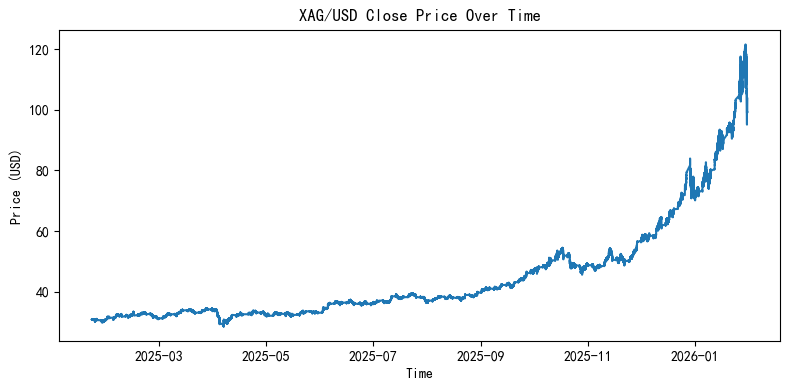

Data cleaning and EDA completed. Ready for feature engineering...


In [4]:
key_cols = ['open', 'high', 'low', 'close', 'volume']
print("=== Key features descriptive statistics ===")
print(xag[key_cols].describe().round(4))

## plot close price over time
plt.figure(figsize=(8, 4))
plt.plot(xag.index, xag['close'])
plt.title('XAG/USD Close Price Over Time')
plt.xlabel('Time')
plt.ylabel('Price (USD)')
plt.tight_layout()
plt.show()
print('Data cleaning and EDA completed. Ready for feature engineering...')

## 1.2 Feature Engineering (HFT factors)

### 1.2.1 Bid-Ask Spread & Order Book Pressure

In [5]:
# define rolling window size
n=10

In [6]:
# F01: Relative Bid-Ask Spread
xag['RS'] = (xag['close_ask'] - xag['close_bid']) / xag['close']
# Price-normalized spread enabling cross-sectional comparison. Negatively correlated with short-horizon returns; 
# widely used as a proxy for the liquidity risk premium.

# F02: Spread Change Z-Score
xag['SCZ'] = (xag['RS'] - xag['RS'].rolling(window=n).mean()) / xag['RS'].rolling(window=n).std()
# Captures sudden liquidity shocks. An abnormally wide spread often precedes large-order market impact; 
# used as a position-sizing or stop-loss trigger in execution models

# F03: Intrabar Spread Asymmetry
xag['ISA'] = ((xag['high_ask'] - xag['high_bid']) - (xag['low_ask'] - xag['low_bid']))/ xag['close']
# Measures within-bar spread imbalance between bid and ask sides. Positive values (ask-side expansion at highs) signal market stress; 
# negative values imply bid-side support.

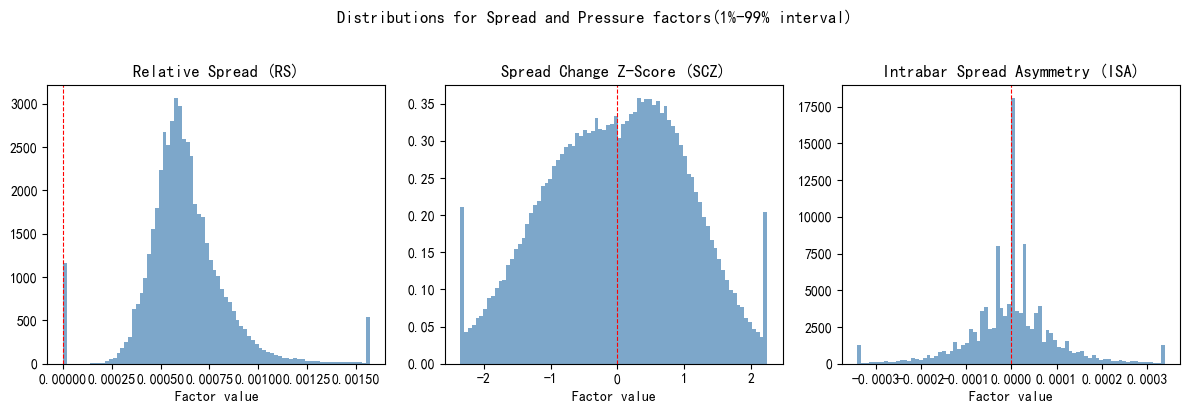

In [7]:
# ──────────────────────────────────────────────────────────────────
# Factor distribution visualization
# ──────────────────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(12, 4))
cols = ['RS', 'SCZ', 'ISA']
titles = ['Relative Spread (RS)', 'Spread Change Z-Score (SCZ)', 'Intrabar Spread Asymmetry (ISA)']

for ax, col, title in zip(axes, cols, titles):
    vals = xag[col].dropna()
    # Observe [1%, 99%] interval to mitigate outliers
    lo, hi = vals.quantile(0.01), vals.quantile(0.99)
    ax.hist(vals.clip(lo, hi), bins=80, color='steelblue', alpha=0.7, density=True)
    ax.set_title(title)
    ax.set_xlabel('Factor value')
    ax.axvline(0, color='red', lw=0.8, ls='--')

plt.suptitle('Distributions for Spread and Pressure factors(1%-99% interval)', y=1.02)
plt.tight_layout()
plt.show()

### 1.2.2 Price Momentum & Mean Reversion

In [8]:
#F04: Mid-Price Log Return
xag['MPR'] = np.log(xag['close'])-np.log(xag['close'].shift(n))
# Log return of the mid-price, eliminating single-sided quote noise. Short lookbacks (5–15 min) tend to mean-revert; 
# longer lookbacks (30–60 min) exhibit momentum persistence.

#F05: Intrabar Price Skewness
xag['IPS'] = (xag['close']-xag['open'])/(xag['high']-xag['low'])
# Analogous to Williams %R. Close near the bar's high (+1) signals bullish dominance; 
# near the low (−1) signals bearish dominance. Predictive of the next bar's direction.

#F06: Open-to-Close Gap
xag['OCG'] = (xag['open'] - xag['close'].shift(1)) / xag['close'].shift(1)
# Inter-bar mid-price gap between successive minutes. At high frequencies, gaps exhibit strong mean-reversion tendencies, 
# forming the basis of scalping and gap-fade strategies.

#F07: Range Expansion Ratio
xag['range'] = xag['high'] - xag['low']
xag['RER'] = xag['range'] / xag['range'].rolling(window=n).mean()
# RER > 1.5 often accompanies trend breakouts; RER < 0.5 indicates price compression (low-volatility regime), 
# frequently preceding explosive directional moves.

#F08: MA Spread / Crossover Signal
xag['MS'] = (xag['close'].rolling(window=5).mean()-xag['close'].rolling(window=20).mean())/xag['close'].rolling(window=20).mean()
# Measures short-term momentum relative to a longer-term trend. Positive values indicate bullish crossover;
# negative values indicate bearish crossover. The magnitude of MS can be used to gauge momentum strength.

#F09: Price Relative to MA20 (Mean-Reversion Signal)
xag['MR'] = (xag['close'] - xag['close'].rolling(window=20).mean()) / xag['close'].rolling(window=20).mean()
# Measures how far the current price deviates from its 20-minute moving average. Extreme positive values suggest overextension and potential mean-reversion;
# extreme negative values suggest overselling and potential mean-reversion.

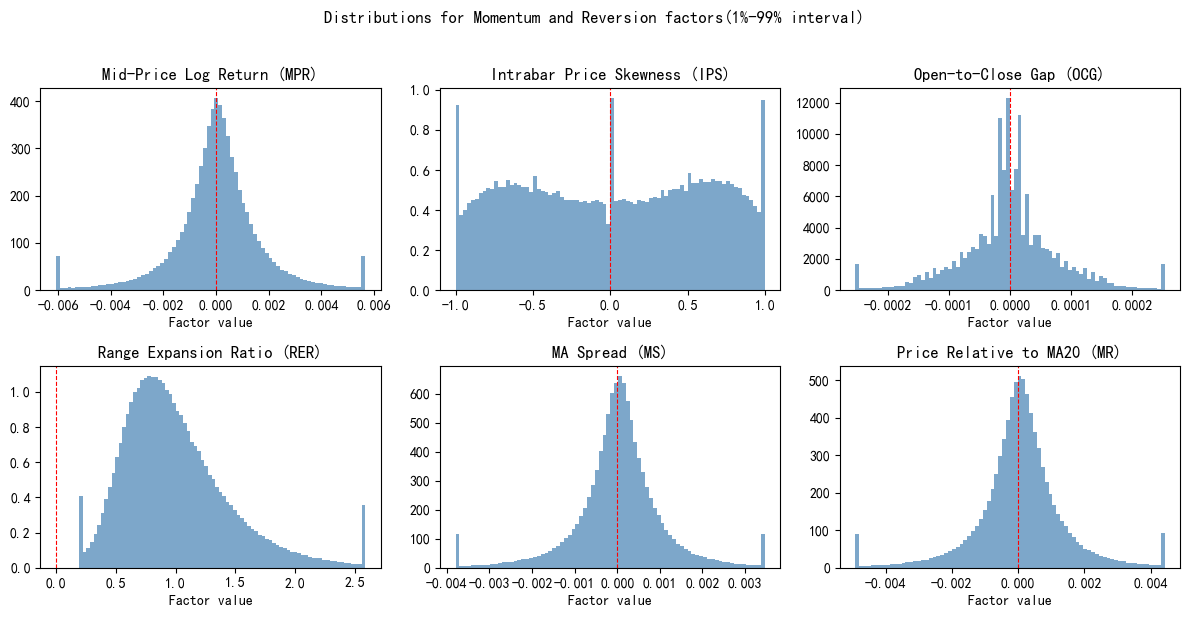

In [9]:
# ──────────────────────────────────────────────────────────────────
# Factor distribution visualization
# ──────────────────────────────────────────────────────────────────
fig, axes = plt.subplots(2, 3, figsize=(12, 6))
cols = ['MPR', 'IPS', 'OCG', 'RER', 'MS', 'MR']
titles = ['Mid-Price Log Return (MPR)', 'Intrabar Price Skewness (IPS)', 'Open-to-Close Gap (OCG)', 'Range Expansion Ratio (RER)', 'MA Spread (MS)', 'Price Relative to MA20 (MR)']

axes = axes.ravel()

for ax, col, title in zip(axes, cols, titles):
    vals = xag[col].dropna()
    # Observe [1%, 99%] interval to mitigate outliers
    lo, hi = vals.quantile(0.01), vals.quantile(0.99)
    ax.hist(vals.clip(lo, hi), bins=80, color='steelblue', alpha=0.7, density=True)
    ax.set_title(title)
    ax.set_xlabel('Factor value')
    ax.axvline(0, color='red', lw=0.8, ls='--')

plt.suptitle('Distributions for Momentum and Reversion factors(1%-99% interval)', y=1.02)
plt.tight_layout()
plt.show()

### 1.2.3 Volume Proxy & Trading Activity

In [10]:
#F10: Volume Density Ratio
xag['VDR'] = xag['volume'] / xag['volume'].rolling(window=n).mean()
# Normalizes current volume activity against its rolling average. VDR significantly above 1 indicates unusual order flow 
# — strongly associated with institutional activity and trend initiation.

#F11: Price-Volume Correlation
xag['delta']=xag['close'].diff()
xag['PVC'] = xag['delta'].rolling(window=n).corr(xag['volume'])
# Rolling correlation between mid-price changes and volume counts. Positive correlation confirms volume-price agreement (trend valid); 
# negative divergence signals potential reversal.

#F12: Volume-Weighted Mid Deviation
xag['amount'] = xag['volume'] * xag['close']
xag['VWAP'] = xag['amount'].rolling(window=n).sum() / xag['volume'].rolling(window=n).sum()
xag['VWMD'] = (xag['close'] - xag['VWAP'])/xag['VWAP']
# VWAP analog using volume counts as volume proxy. Deviation from volume-weighted average is a mean-reversion signal; 
# persistent one-sided deviation indicates informed order flow.

#F13: Volume Acceleration
xag['VACC_R'] = (xag['volume'] - xag['volume'].shift(1))/xag['volume'].shift(1)
# First difference of volume counts — an activity acceleration indicator. Sustained volume acceleration is a hallmark of 
# algorithmic order slicing (TWAP/VWAP execution), predicting short-term price continuation.

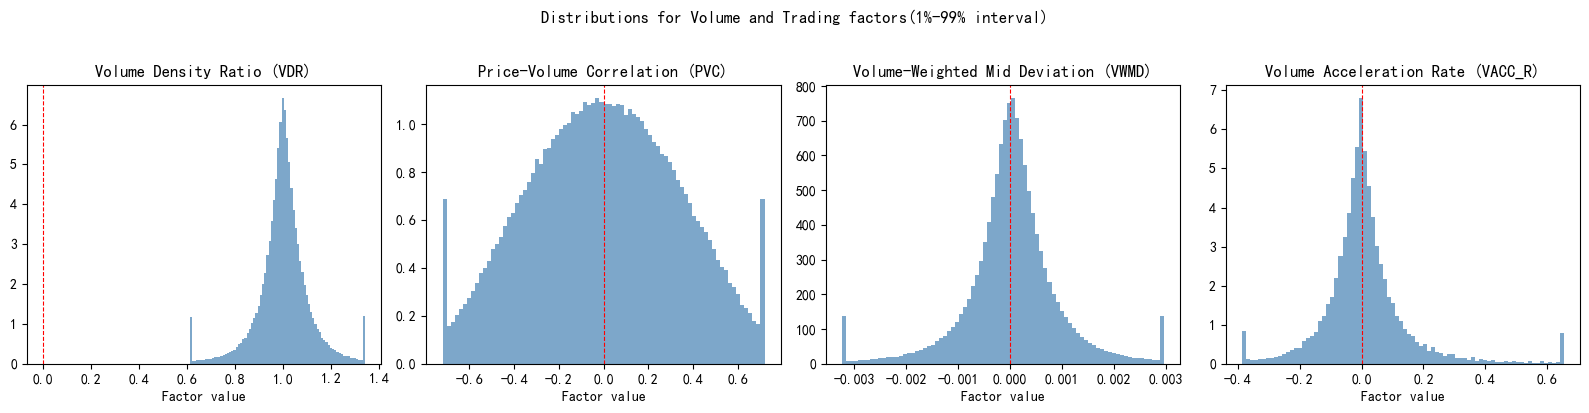

In [11]:
# ──────────────────────────────────────────────────────────────────
# Factor distribution visualization
# ──────────────────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 4, figsize=(16, 4))
cols = ['VDR', 'PVC', 'VWMD', 'VACC_R']
titles = ['Volume Density Ratio (VDR)', 'Price-Volume Correlation (PVC)', 'Volume-Weighted Mid Deviation (VWMD)', 'Volume Acceleration Rate (VACC_R)']

for ax, col, title in zip(axes, cols, titles):
    vals = xag[col].dropna()
    # Observe [1%, 99%] interval to mitigate outliers
    lo, hi = vals.quantile(0.01), vals.quantile(0.99)
    ax.hist(vals.clip(lo, hi), bins=80, color='steelblue', alpha=0.7, density=True)
    ax.set_title(title)
    ax.set_xlabel('Factor value')
    ax.axvline(0, color='red', lw=0.8, ls='--')

plt.suptitle('Distributions for Volume and Trading factors(1%-99% interval)', y=1.02)
plt.tight_layout()
plt.show()

### 1.2.4 Volatility & Risk Factors

In [12]:
## F14:Parkinson Volatility
xag['Parkinson']=np.log(xag['high']/xag['low'])**2
xag['PV'] = np.sqrt(xag['Parkinson'].rolling(window=n).mean()/(4*np.log(2)))
# Efficient range-based volatility estimator utilizing high and low prices. Reduces estimator variance by 
# ~5× versus close-to-close estimators — essential for noisy minute-level data.

# F15: Garman-Klass Volatility
xag['GKV'] = 0.5 * np.log((xag['high']/xag['low'])**2) - (2*np.log(2)-1) * np.log((xag['close']/xag['open'])**2)
# Optimal unbiased estimator exploiting all four OHLC prices. Compute independently on bid and ask series and average. 
# Outperforms Parkinson by further incorporating open-close information.

#F16: Volatility Regime Ratio
short = 5
long = 60
xag['VRR'] = xag['PV'].rolling(window=short).mean() / xag['PV'].rolling(window=long).mean()
# Short-to-long realized volatility ratio. VRR > 1 flags abnormal near-term turbulence (risk-off signal); 
# rising VRR trend often precedes large directional breaks. Central to regime detection.

#F17: Bid-Ask Volatility Asymmetry
xag['BVA'] = xag['close_bid'].rolling(window=n).std() / xag['close_ask'].rolling(window=n).std()
# Volatility differential between bid and ask quote series. Positive BVA (bid more volatile) implies elevated buy-side pressure; 
# negative implies sell-side dominance. Reflects structural order book imbalance.

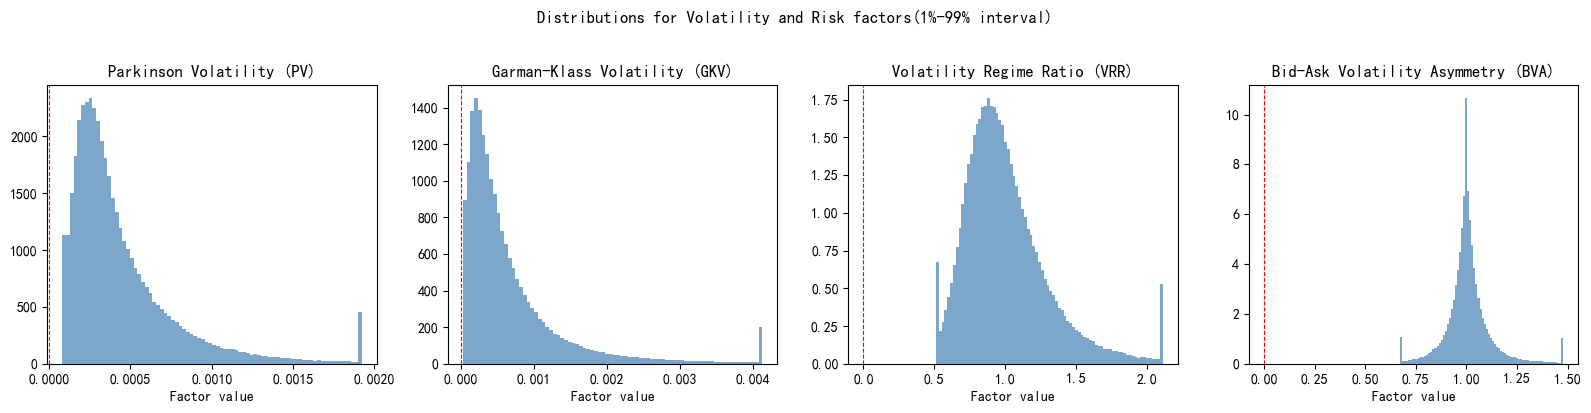

In [13]:
# ──────────────────────────────────────────────────────────────────
# Factor distribution visualization
# ──────────────────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 4, figsize=(16, 4))
cols = ['PV', 'GKV', 'VRR', 'BVA']
titles = ['Parkinson Volatility (PV)', 'Garman-Klass Volatility (GKV)', 'Volatility Regime Ratio (VRR)', 'Bid-Ask Volatility Asymmetry (BVA)']

for ax, col, title in zip(axes, cols, titles):
    vals = xag[col].dropna()
    # Observe [1%, 99%] interval to mitigate outliers
    lo, hi = vals.quantile(0.01), vals.quantile(0.99)
    ax.hist(vals.clip(lo, hi), bins=80, color='steelblue', alpha=0.7, density=True)
    ax.set_title(title)
    ax.set_xlabel('Factor value')
    ax.axvline(0, color='red', lw=0.8, ls='--')

plt.suptitle('Distributions for Volatility and Risk factors(1%-99% interval)', y=1.02)
plt.tight_layout()
plt.show()

### 1.2.5 Market Microstructure & Information Flow

In [14]:
#F18: Roll Implied Spread
xag['delta_lag1']=xag['delta'].shift(1)
xag['cov'] = xag['delta'].rolling(window=n).cov(xag['delta_lag1'])
xag['RIS']= 2 * np.sqrt(np.maximum(-xag['cov'], 0))
# Classic Roll (1984) estimator that recovers the implicit spread from the serial covariance of mid-price changes. 
# Negative covariance is the microstructure fingerprint of the bid-ask bounce.

#F19: Kyle's Lambda (Price Impact)
xag['OF'] = np.sign(xag['delta']) * xag['volume']
cov_xy = xag['delta'].rolling(window=n).cov(xag['OF'])
var_x = xag['OF'].rolling(window=n).var()
xag['KL'] = cov_xy / var_x
# Kyle (1985) price impact coefficient estimated with volume as an order flow proxy. 
# λ̂ measures per-unit flow impact on price — a direct gauge of information asymmetry and market depth.

#F20: Amihud Illiquidity Ratio
xag['ILLIQ'] = abs(xag['delta']) / xag['volume']
xag['AIR'] = xag['ILLIQ'].rolling(window=n).mean()
# Amihud (2002) illiquidity ratio adapted to minute bars 
# Higher AIR means greater price impact per unit of order flow — illiquidity risk premium proxy.

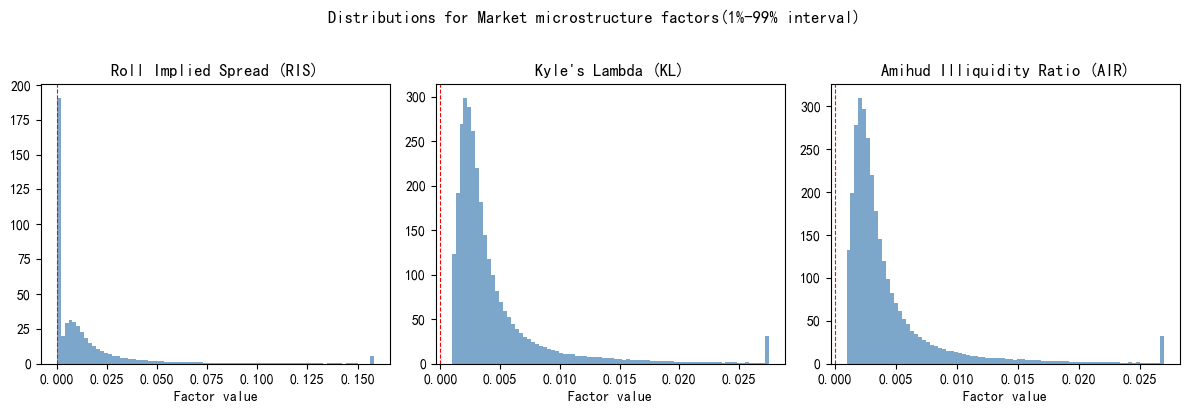

In [15]:
# ──────────────────────────────────────────────────────────────────
# Factor distribution visualization
# ──────────────────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(12, 4))
cols = ['RIS', 'KL', 'AIR']
titles = ['Roll Implied Spread (RIS)', "Kyle's Lambda (KL)", 'Amihud Illiquidity Ratio (AIR)']

for ax, col, title in zip(axes, cols, titles):
    vals = xag[col].dropna()
    # Observe [1%, 99%] interval to mitigate outliers
    lo, hi = vals.quantile(0.01), vals.quantile(0.99)
    ax.hist(vals.clip(lo, hi), bins=80, color='steelblue', alpha=0.7, density=True)
    ax.set_title(title)
    ax.set_xlabel('Factor value')
    ax.axvline(0, color='red', lw=0.8, ls='--')

plt.suptitle('Distributions for Market microstructure factors(1%-99% interval)', y=1.02)
plt.tight_layout()
plt.show()

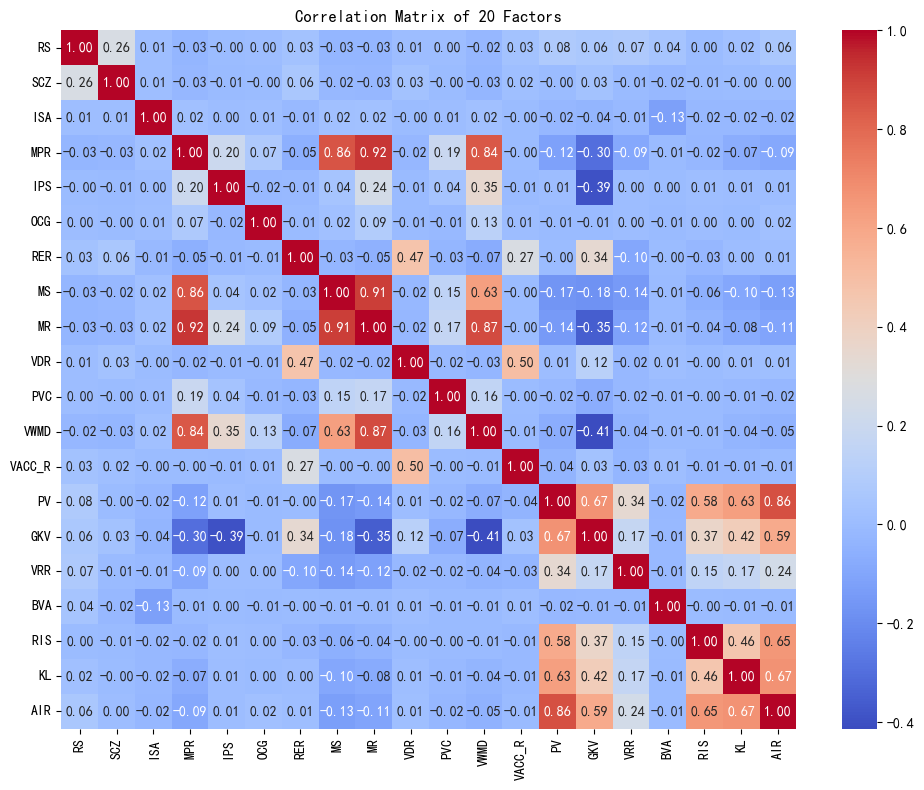

In [16]:
# factor correlation heatmap
plt.figure(figsize=(10, 8))
BASE_FACTORS = ['RS', 'SCZ', 'ISA', 'MPR', 'IPS', 'OCG', 'RER', 'MS', 'MR', 'VDR', 'PVC', 'VWMD', 'VACC_R', 'PV', 'GKV', 'VRR', 'BVA', 'RIS', 'KL', 'AIR']
corr_matrix = xag[BASE_FACTORS].corr()
sns.heatmap(corr_matrix, annot=True, fmt=".2f", cmap='coolwarm', cbar=True)
plt.title('Correlation Matrix of 20 Factors')
plt.tight_layout()
plt.show()


### 1.2.6 Factor Addition

In [17]:
# Factor addition: time features, and volatility regime features
def add_time_features(df):
    out = df.copy()
    idx = out.index

    # Intraday time features
    # Cyclical encoding
    out["hour_sin"] = np.sin(2 * np.pi * idx.hour / 24)
    out["hour_cos"] = np.cos(2 * np.pi * idx.hour / 24)
    out["minute_sin"] = np.sin(2 * np.pi * idx.minute / 60)
    out["minute_cos"] = np.cos(2 * np.pi * idx.minute / 60)

    # Session flags
    out["is_asia_session"] = ((idx.hour >= 0) & (idx.hour < 8)).astype(int)
    out["is_europe_session"] = ((idx.hour >= 8) & (idx.hour < 16)).astype(int)
    out["is_us_session"] = ((idx.hour >= 13) & (idx.hour < 21)).astype(int)

    return out

def add_regime_features(df):
    out = df.copy()

    # Volatility regime features
    out['MA10'] = out['close'].rolling(10).mean()
    out['Return'] = out["close"].pct_change()
    out["Volatility"] = out["Return"].rolling(10).std()

    q_low = out["Volatility"].rolling(500).quantile(0.33)
    q_high = out["Volatility"].rolling(500).quantile(0.66)

    out["regime_low_vol"] = (out["Volatility"] <= q_low).astype(int)
    out["regime_high_vol"] = (out["Volatility"] >= q_high).astype(int)

    return out

# Apply feature expansion
xag = add_time_features(xag)
xag = add_regime_features(xag)

TEST_FACTORS = BASE_FACTORS+['hour_sin','hour_cos','minute_sin','minute_cos','is_asia_session','is_europe_session','is_us_session','regime_low_vol', 'regime_high_vol']

## 1.3 Factor Testing

In [18]:
# Calculate forward returns for 5min, 10min, 20min, and 50min
xag['ret_5m'] = (xag['close'].shift(-5) - xag['close']) / xag['close']
xag['ret_10m'] = (xag['close'].shift(-10) - xag['close']) / xag['close']
xag['ret_20m'] = (xag['close'].shift(-20) - xag['close']) / xag['close']
xag['ret_50m'] = (xag['close'].shift(-50) - xag['close']) / xag['close']

## Drop rows with NaN values
xag = xag.dropna(subset=['ret_5m', 'ret_10m', 'ret_20m', 'ret_50m'])
print("Forward return calculation completed")
print(xag[['ret_5m', 'ret_10m', 'ret_20m', 'ret_50m']].describe().round(4))

## generate trend labels with different thresholds for different horizons
xag['trend_5m'] = np.where(xag['ret_5m'] > 0.0005, 2, np.where(xag['ret_5m'] < -0.0005, 0, 1))
xag['trend_10m'] = np.where(xag['ret_10m'] > 0.0007, 2, np.where(xag['ret_10m'] < -0.0007, 0, 1))
xag['trend_20m'] = np.where(xag['ret_20m'] > 0.001, 2, np.where(xag['ret_20m'] < -0.001, 0, 1))
xag['trend_50m'] = np.where(xag['ret_50m'] > 0.0014, 2, np.where(xag['ret_50m'] < -0.0014, 0, 1))

Forward return calculation completed
            ret_5m      ret_10m      ret_20m      ret_50m
count  359750.0000  359750.0000  359750.0000  359750.0000
mean        0.0000       0.0000       0.0001       0.0002
std         0.0015       0.0021       0.0030       0.0047
min        -0.0549      -0.0632      -0.0834      -0.1103
25%        -0.0005      -0.0007      -0.0010      -0.0014
50%         0.0000       0.0001       0.0001       0.0002
75%         0.0006       0.0008       0.0012       0.0019
max         0.0394       0.0438       0.0590       0.0644


In [19]:
# ──────────────────────────────────────────────────────────────────
# IC testing：every n-minute period Pearson IC 和 Rank IC
# ──────────────────────────────────────────────────────────────────
def compute_ic_series(df, factor_col, ret_col, n):
    """every n-minute period compute Pearson IC and Rank IC(Spearman)"""
    ic_list = []
    for i in range(0, len(df) - n, n):
        factor_values = df[factor_col].iloc[i:i+n]
        returns = df[ret_col].iloc[i:i+n]
        if len(factor_values) > 1 and len(returns) > 1:
            pearson_ic = factor_values.corr(returns)
            rank_ic, _ = spearmanr(factor_values, returns)
            ic_list.append({'time': df.index[i], 'IC': pearson_ic, 'RankIC': rank_ic})
    return pd.DataFrame(ic_list).set_index("time")

period = 600
# Compute all factors'IC to 5-minute future return
print("=== IC testing result summary (ret_5m) ===\n")
for fac in TEST_FACTORS:
    ic_s = compute_ic_series(xag, fac, 'ret_5m', period)
    ic_mean   = ic_s['IC'].mean()
    ic_std    = ic_s['IC'].std()
    icir      = ic_mean / ic_std if ic_std > 0 else 0
    rank_mean = ic_s['RankIC'].mean()
    rank_ir   = rank_mean / ic_s['RankIC'].std() if ic_s['RankIC'].std() > 0 else 0
    pos_pct   = (ic_s['IC'] > 0).mean() * 100
    print(f"{fac:20s} | IC={ic_mean:+.4f}  IC_IR={icir:+.3f}  "
          f"RankIC={rank_mean:+.4f}  RankIR={rank_ir:+.3f}  Positive IC percentage={pos_pct:.1f}%")

=== IC testing result summary (ret_5m) ===

RS                   | IC=+0.0101  IC_IR=+0.138  RankIC=+0.0151  RankIR=+0.220  Positive IC percentage=55.1%
SCZ                  | IC=+0.0009  IC_IR=+0.016  RankIC=+0.0010  RankIR=+0.017  Positive IC percentage=50.1%
ISA                  | IC=+0.0024  IC_IR=+0.045  RankIC=+0.0043  RankIR=+0.088  Positive IC percentage=49.4%
MPR                  | IC=-0.0403  IC_IR=-0.371  RankIC=-0.0460  RankIR=-0.523  Positive IC percentage=33.7%
IPS                  | IC=-0.0087  IC_IR=-0.187  RankIC=-0.0187  RankIR=-0.417  Positive IC percentage=40.9%
OCG                  | IC=-0.0049  IC_IR=-0.098  RankIC=-0.0049  RankIR=-0.118  Positive IC percentage=45.9%
RER                  | IC=+0.0044  IC_IR=+0.081  RankIC=+0.0043  RankIR=+0.091  Positive IC percentage=54.4%
MS                   | IC=-0.0418  IC_IR=-0.389  RankIC=-0.0467  RankIR=-0.522  Positive IC percentage=33.4%
MR                   | IC=-0.0486  IC_IR=-0.443  RankIC=-0.0547  RankIR=-0.605  Posi

In [20]:
# Compute all factors'IC to 10-minute future return
print("=== IC testing result summary (ret_10m) ===\n")
for fac in TEST_FACTORS:
    ic_s = compute_ic_series(xag, fac, 'ret_10m', period)
    ic_mean   = ic_s['IC'].mean()
    ic_std    = ic_s['IC'].std()
    icir      = ic_mean / ic_std if ic_std > 0 else 0
    rank_mean = ic_s['RankIC'].mean()
    rank_ir   = rank_mean / ic_s['RankIC'].std() if ic_s['RankIC'].std() > 0 else 0
    pos_pct   = (ic_s['IC'] > 0).mean() * 100
    print(f"{fac:20s} | IC={ic_mean:+.4f}  IC_IR={icir:+.3f}  "
          f"RankIC={rank_mean:+.4f}  RankIR={rank_ir:+.3f}  Positive IC percentage={pos_pct:.1f}%")

=== IC testing result summary (ret_10m) ===

RS                   | IC=+0.0126  IC_IR=+0.140  RankIC=+0.0195  RankIR=+0.226  Positive IC percentage=53.8%
SCZ                  | IC=+0.0030  IC_IR=+0.053  RankIC=+0.0028  RankIR=+0.048  Positive IC percentage=50.3%
ISA                  | IC=+0.0031  IC_IR=+0.053  RankIC=+0.0046  RankIR=+0.083  Positive IC percentage=50.1%
MPR                  | IC=-0.0500  IC_IR=-0.391  RankIC=-0.0546  RankIR=-0.516  Positive IC percentage=32.7%
IPS                  | IC=-0.0118  IC_IR=-0.258  RankIC=-0.0220  RankIR=-0.517  Positive IC percentage=39.6%
OCG                  | IC=-0.0076  IC_IR=-0.152  RankIC=-0.0078  RankIR=-0.171  Positive IC percentage=42.7%
RER                  | IC=+0.0037  IC_IR=+0.075  RankIC=+0.0034  RankIR=+0.076  Positive IC percentage=53.6%
MS                   | IC=-0.0540  IC_IR=-0.402  RankIC=-0.0582  RankIR=-0.503  Positive IC percentage=34.1%
MR                   | IC=-0.0625  IC_IR=-0.462  RankIC=-0.0667  RankIR=-0.583  Pos

In [21]:
# Compute all factors'IC to 20-minute future return
print("=== IC testing result summary (ret_20m) ===\n")
for fac in TEST_FACTORS:
    ic_s = compute_ic_series(xag, fac, 'ret_20m', period)
    ic_mean   = ic_s['IC'].mean()
    ic_std    = ic_s['IC'].std()
    icir      = ic_mean / ic_std if ic_std > 0 else 0
    rank_mean = ic_s['RankIC'].mean()
    rank_ir   = rank_mean / ic_s['RankIC'].std() if ic_s['RankIC'].std() > 0 else 0
    pos_pct   = (ic_s['IC'] > 0).mean() * 100
    print(f"{fac:20s} | IC={ic_mean:+.4f}  IC_IR={icir:+.3f}  "
          f"RankIC={rank_mean:+.4f}  RankIR={rank_ir:+.3f}  Positive IC percentage={pos_pct:.1f}%")

=== IC testing result summary (ret_20m) ===

RS                   | IC=+0.0127  IC_IR=+0.112  RankIC=+0.0215  RankIR=+0.193  Positive IC percentage=53.6%
SCZ                  | IC=+0.0031  IC_IR=+0.060  RankIC=+0.0018  RankIR=+0.033  Positive IC percentage=51.4%
ISA                  | IC=+0.0031  IC_IR=+0.046  RankIC=+0.0043  RankIR=+0.068  Positive IC percentage=50.8%
MPR                  | IC=-0.0652  IC_IR=-0.480  RankIC=-0.0666  RankIR=-0.572  Positive IC percentage=29.7%
IPS                  | IC=-0.0166  IC_IR=-0.371  RankIC=-0.0243  RankIR=-0.576  Positive IC percentage=33.9%
OCG                  | IC=-0.0072  IC_IR=-0.144  RankIC=-0.0090  RankIR=-0.189  Positive IC percentage=42.1%
RER                  | IC=+0.0037  IC_IR=+0.088  RankIC=+0.0039  RankIR=+0.100  Positive IC percentage=53.1%
MS                   | IC=-0.0692  IC_IR=-0.451  RankIC=-0.0691  RankIR=-0.511  Positive IC percentage=31.1%
MR                   | IC=-0.0768  IC_IR=-0.501  RankIC=-0.0770  RankIR=-0.572  Pos

In [22]:
# Compute all factors'IC to 50-minute future return
print("=== IC testing result summary (ret_50m) ===\n")
for fac in TEST_FACTORS:
    ic_s = compute_ic_series(xag, fac, 'ret_50m', period)
    ic_mean   = ic_s['IC'].mean()
    ic_std    = ic_s['IC'].std()
    icir      = ic_mean / ic_std if ic_std > 0 else 0
    rank_mean = ic_s['RankIC'].mean()
    rank_ir   = rank_mean / ic_s['RankIC'].std() if ic_s['RankIC'].std() > 0 else 0
    pos_pct   = (ic_s['IC'] > 0).mean() * 100
    print(f"{fac:20s} | IC={ic_mean:+.4f}  IC_IR={icir:+.3f}  "
          f"RankIC={rank_mean:+.4f}  RankIR={rank_ir:+.3f}  Positive IC percentage={pos_pct:.1f}%")

=== IC testing result summary (ret_50m) ===

RS                   | IC=+0.0139  IC_IR=+0.095  RankIC=+0.0275  RankIR=+0.185  Positive IC percentage=53.3%
SCZ                  | IC=+0.0043  IC_IR=+0.104  RankIC=+0.0050  RankIR=+0.118  Positive IC percentage=53.8%
ISA                  | IC=+0.0011  IC_IR=+0.014  RankIC=+0.0030  RankIR=+0.038  Positive IC percentage=47.7%
MPR                  | IC=-0.0807  IC_IR=-0.621  RankIC=-0.0767  RankIR=-0.656  Positive IC percentage=25.7%
IPS                  | IC=-0.0201  IC_IR=-0.481  RankIC=-0.0252  RankIR=-0.632  Positive IC percentage=30.2%
OCG                  | IC=-0.0059  IC_IR=-0.120  RankIC=-0.0068  RankIR=-0.138  Positive IC percentage=44.2%
RER                  | IC=+0.0033  IC_IR=+0.099  RankIC=+0.0040  RankIR=+0.125  Positive IC percentage=51.8%
MS                   | IC=-0.0919  IC_IR=-0.599  RankIC=-0.0853  RankIR=-0.605  Positive IC percentage=26.9%
MR                   | IC=-0.0963  IC_IR=-0.631  RankIC=-0.0905  RankIR=-0.651  Pos

In [23]:
# Factor expansion: add lag terms, change terms to high RankIC factors
def add_factor_transforms(df, factor_cols, lags=(1, 5, 20)):
    out = df.copy()

    for f in factor_cols:
        for l in lags:
            out[f"{f}_lag{l}"] = out[f].shift(l)          # 1) Lag features: capture persistence
            out[f"{f}_ret{l}"] = out[f].pct_change(l)     # 2) Change features: capture factor momentum
        
    return out

xag = add_factor_transforms(xag, BASE_FACTORS, lags=(1, 5, 20))
FACTORS_EXPANDED = BASE_FACTORS + xag.columns.tolist()[-120:] + ['hour_sin','hour_cos','minute_sin','minute_cos','is_asia_session','is_europe_session','is_us_session','regime_low_vol', 'regime_high_vol']

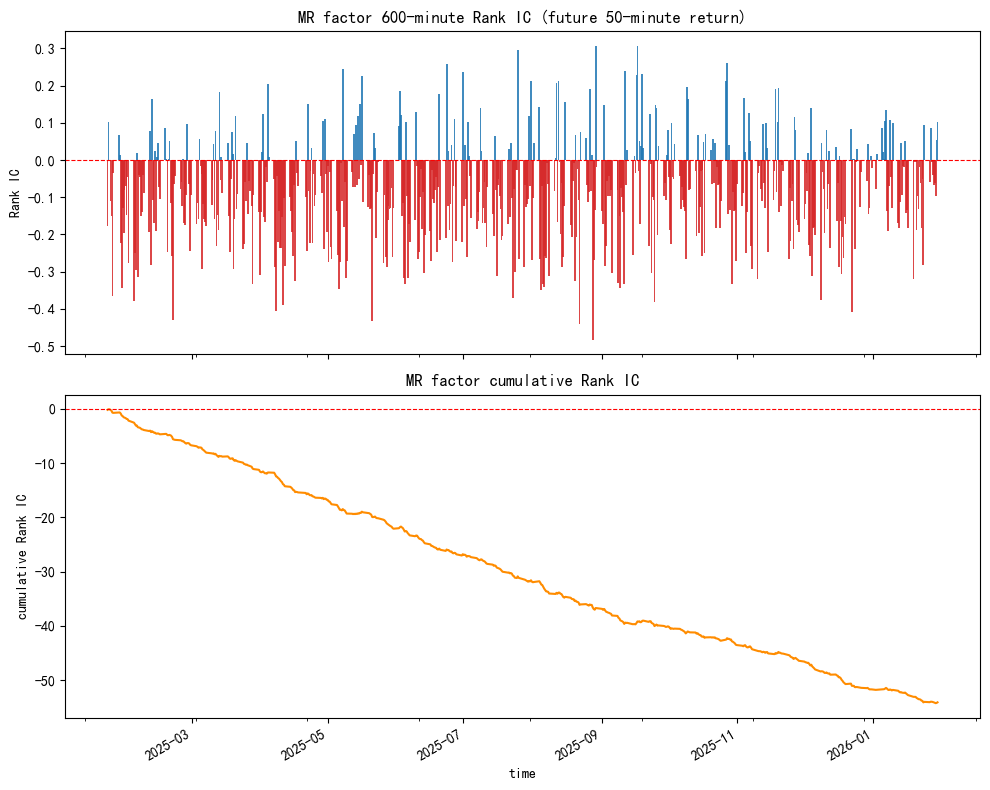

In [24]:
# ──────────────────────────────────────────────────────────────────
# MR factor's Rank IC and cumulative value
# ──────────────────────────────────────────────────────────────────
ic_mr_50min = compute_ic_series(xag, 'MR', 'ret_50m', period)

colors = ['#d62728' if v < 0 else '#1f77b4' for v in ic_mr_50min['RankIC']]
fig, axes = plt.subplots(2, 1, figsize=(10, 8), sharex=True)

axes[0].bar(ic_mr_50min.index, ic_mr_50min['RankIC'], width=0.8, color=colors, alpha=0.85)
axes[0].axhline(0, color='red', lw=0.8, ls='--')
axes[0].set_title(f'MR factor {period}-minute Rank IC (future 50-minute return)')
axes[0].set_ylabel('Rank IC')

ic_mr_50min['RankIC'].cumsum().plot(ax=axes[1], color='darkorange')
axes[1].axhline(0, color='red', lw=0.8, ls='--')
axes[1].set_title('MR factor cumulative Rank IC')
axes[1].set_ylabel('cumulative Rank IC')
axes[1].set_xlabel('time')

plt.tight_layout()
plt.show()

## 1.4 Model Evaluation

In [6]:
from sklearn.preprocessing import StandardScaler
from sklearn.preprocessing import label_binarize
from sklearn.decomposition import PCA
from sklearn.metrics import (accuracy_score, precision_score, recall_score, f1_score, log_loss, roc_auc_score)

def clean_X(X_train_df, X_val_df):
    # 1) inf -> nan
    X_train = X_train_df.replace([np.inf, -np.inf], np.nan).copy()
    X_val = X_val_df.replace([np.inf, -np.inf], np.nan).copy()

    # 2) use training set's μ±3σ to clip extreme values in both training and validation sets
    mu = X_train.mean()
    sigma = X_train.std()
    X_train = X_train.clip(lower=mu - 3 * sigma, upper=mu + 3 * sigma, axis=1)
    X_val = X_val.clip(lower=mu - 3 * sigma, upper=mu + 3 * sigma, axis=1)

    # 3) use training set's median to fill missing values in both training and validation sets
    med = X_train.median()
    X_train = X_train.fillna(med)
    X_val = X_val.fillna(med)

    # 4) after clipping and filling, if there are still nan values, replace them with 0
    X_train = X_train.replace(np.nan, 0.0)
    X_val = X_val.replace(np.nan, 0.0)

    return X_train.values, X_val.values

def rolling_backtest(df,factor_cols,target_col,model,
                     training_size,embargo,validation_size,step_size,
                     use_pca=False,pca_keep=0.8):
    """Rolling window backtest for classification model"""
    classification_metrics = []
    df_list = []

    for start in tqdm(range(0, len(df) - training_size - embargo - validation_size+1, step_size)):
        train_start = start
        train_end = start + training_size
        val_start = train_end + embargo
        val_end = val_start + validation_size
        
        train_df = df.iloc[train_start:train_end].copy()
        val_df = df.iloc[val_start:val_end].copy()

        X_train_df = train_df[factor_cols]
        X_val_df = val_df[factor_cols]
        y_train = train_df[target_col].values
        y_val = val_df[target_col].values

        # Step 1: data cleaning for features
        X_train, X_val = clean_X(X_train_df, X_val_df)

        # Step 2: standardize features using training set's parameters
        scaler = StandardScaler()
        X_train = scaler.fit_transform(X_train)
        X_val = scaler.transform(X_val)

        # Step 3(Optional): dimensionality reduction with PCA (fit on training set only)
        if use_pca:
            pca = PCA(n_components=pca_keep, svd_solver='full')  # retain specified percentage of the variance
            X_train = pca.fit_transform(X_train)
            X_val = pca.transform(X_val)

        model.fit(X_train, y_train)
        pred_trend = model.predict(X_val)  # predicted class labels
        pred_proba = model.predict_proba(X_val)  # predicted probabilities for each class
        y_onehot = label_binarize(y_val, classes=[0, 1, 2])
        val_df['pred_trend'] = pred_trend  # predicted class labels
        val_df['prob_down'] = pred_proba[:, 0]  # probability of down class
        val_df['prob_noise'] = pred_proba[:, 1]  # probability of noise class
        val_df['prob_up'] = pred_proba[:, 2]  # probability of positive class

        # append the validation DataFrame to the full DataFrame
        classification_metrics.append({
            'time': val_df.index[0],
            'accuracy': accuracy_score(y_val, pred_trend),
            'precision': precision_score(y_val, pred_trend, average='macro', zero_division=0),
            'recall': recall_score(y_val, pred_trend, average='macro', zero_division=0),
            'f1': f1_score(y_val, pred_trend, average='macro', zero_division=0),
            'log_loss': log_loss(y_val, pred_proba, labels=[0, 1, 2]),
            'brier_score': np.mean(np.sum((y_onehot - pred_proba) ** 2, axis=1)),
            'roc_auc': roc_auc_score(y_onehot, pred_proba, multi_class='ovr'),  # ROC AUC for multi-class classification
        })
        df_list.append(val_df[['close', target_col, 'pred_trend', 'prob_down', 'prob_noise', 'prob_up']])
    
    return pd.DataFrame(classification_metrics).set_index('time'), pd.concat(df_list)

# employ rolling window for training and validation
training_size = 1800  # training window size
validation_size = 200  # validation window size
step_size = 1800  # step size for rolling window

### 1.4.1 Logistic Regression

In [26]:
# ──────────────────────────────────────────────────────────────────
# Logistic regression backtest using all factors to predict n-minute future trend
# ──────────────────────────────────────────────────────────────────
from sklearn.linear_model import LogisticRegression
## Create different logistic regression models(plain, lasso, ridge, elasticnet) for comparison
logistic_models={
    'LR_plain': LogisticRegression(solver='lbfgs', max_iter=1000, random_state=42),
    'LR_lasso': LogisticRegression(penalty='l1', solver='saga', max_iter=1000, random_state=42),
    'LR_ridge': LogisticRegression(penalty='l2', solver='lbfgs', max_iter=1000, random_state=42),
    'LR_elasticnet': LogisticRegression(penalty='elasticnet', solver='saga', l1_ratio=0.5, max_iter=1000, random_state=42)
}

# Summarize metrics for logistic models on 5-minute future trend
print("=== Logistic Regression metrics summary (trend_5m) ===\n")
TARGET_COL = 'trend_5m'
embargo = 5
for name, model in logistic_models.items():
    df_metric, df_full = rolling_backtest(xag, FACTORS_EXPANDED, TARGET_COL, model, training_size, embargo, validation_size, step_size, use_pca=True, pca_keep=0.8)
    acc_mean = df_metric['accuracy'].mean()
    prec_mean = df_metric['precision'].mean()
    rec_mean = df_metric['recall'].mean()
    f1_mean = df_metric['f1'].mean()
    log_loss_mean = df_metric['log_loss'].mean()
    brier_mean = df_metric['brier_score'].mean()
    auc_mean = df_metric['roc_auc'].mean()
    pca_tag = "(with PCA)  "
    model_name = f"{name} {pca_tag}"

    print(f"{model_name:30s} | Accuracy={acc_mean:.4f}  Precision={prec_mean:.4f}  "
            f"Recall={rec_mean:.4f}  F1={f1_mean:.4f}  Log Loss={log_loss_mean:.4f}  Brier Score={brier_mean:.4f}  AUC={auc_mean:.4f}  ")

=== Logistic Regression metrics summary (trend_5m) ===



100%|██████████| 199/199 [00:27<00:00,  7.28it/s]


LR_plain (with PCA)            | Accuracy=0.4980  Precision=0.3574  Recall=0.3558  F1=0.3199  Log Loss=1.0368  Brier Score=0.6145  AUC=0.5397  


100%|██████████| 199/199 [01:35<00:00,  2.09it/s]


LR_lasso (with PCA)            | Accuracy=0.4991  Precision=0.3566  Recall=0.3558  F1=0.3191  Log Loss=1.0339  Brier Score=0.6132  AUC=0.5401  


100%|██████████| 199/199 [00:29<00:00,  6.64it/s]


LR_ridge (with PCA)            | Accuracy=0.4980  Precision=0.3574  Recall=0.3558  F1=0.3199  Log Loss=1.0368  Brier Score=0.6145  AUC=0.5397  


100%|██████████| 199/199 [02:24<00:00,  1.38it/s]

LR_elasticnet (with PCA)       | Accuracy=0.4987  Precision=0.3577  Recall=0.3560  F1=0.3197  Log Loss=1.0353  Brier Score=0.6138  AUC=0.5398  


In [27]:
# Summarize metrics for logistic models on 10-minute future trend
print("=== Logistic Regression metrics summary (trend_10m) ===\n")
TARGET_COL = 'trend_10m'
embargo = 10
for name, model in logistic_models.items():
    df_metric, df_full = rolling_backtest(xag, FACTORS_EXPANDED, TARGET_COL, model, training_size, embargo, validation_size, step_size, use_pca=True, pca_keep=0.8)
    acc_mean = df_metric['accuracy'].mean()
    prec_mean = df_metric['precision'].mean()
    rec_mean = df_metric['recall'].mean()
    f1_mean = df_metric['f1'].mean()
    log_loss_mean = df_metric['log_loss'].mean()
    brier_mean = df_metric['brier_score'].mean()
    auc_mean = df_metric['roc_auc'].mean()
    pca_tag = "(with PCA)  "
    model_name = f"{name} {pca_tag}"

    print(f"{model_name:30s} | Accuracy={acc_mean:.4f}  Precision={prec_mean:.4f}  "
            f"Recall={rec_mean:.4f}  F1={f1_mean:.4f}  Log Loss={log_loss_mean:.4f}  Brier Score={brier_mean:.4f}  AUC={auc_mean:.4f}  ")

=== Logistic Regression metrics summary (trend_10m) ===



100%|██████████| 199/199 [00:27<00:00,  7.24it/s]


LR_plain (with PCA)            | Accuracy=0.4860  Precision=0.3535  Recall=0.3535  F1=0.3146  Log Loss=1.0687  Brier Score=0.6314  AUC=0.5345  


100%|██████████| 199/199 [01:34<00:00,  2.10it/s]


LR_lasso (with PCA)            | Accuracy=0.4871  Precision=0.3561  Recall=0.3539  F1=0.3143  Log Loss=1.0651  Brier Score=0.6299  AUC=0.5347  


100%|██████████| 199/199 [00:28<00:00,  7.09it/s]


LR_ridge (with PCA)            | Accuracy=0.4860  Precision=0.3535  Recall=0.3535  F1=0.3146  Log Loss=1.0687  Brier Score=0.6314  AUC=0.5345  


100%|██████████| 199/199 [02:24<00:00,  1.37it/s]

LR_elasticnet (with PCA)       | Accuracy=0.4862  Precision=0.3536  Recall=0.3535  F1=0.3142  Log Loss=1.0669  Brier Score=0.6306  AUC=0.5346  


In [28]:
# Summarize metrics for logistic models on 20-minute future trend
print("=== Logistic Regression metrics summary (trend_20m) ===\n")
TARGET_COL = 'trend_20m'
embargo = 20
for name, model in logistic_models.items():
    df_metric, df_full = rolling_backtest(xag, FACTORS_EXPANDED, TARGET_COL, model, training_size, embargo, validation_size, step_size, use_pca=True, pca_keep=0.8)
    acc_mean = df_metric['accuracy'].mean()
    prec_mean = df_metric['precision'].mean()
    rec_mean = df_metric['recall'].mean()
    f1_mean = df_metric['f1'].mean()
    log_loss_mean = df_metric['log_loss'].mean()
    brier_mean = df_metric['brier_score'].mean()
    auc_mean = df_metric['roc_auc'].mean()
    pca_tag = "(with PCA)  "
    model_name = f"{name} {pca_tag}"

    print(f"{model_name:30s} | Accuracy={acc_mean:.4f}  Precision={prec_mean:.4f}  "
            f"Recall={rec_mean:.4f}  F1={f1_mean:.4f}  Log Loss={log_loss_mean:.4f}  Brier Score={brier_mean:.4f}  AUC={auc_mean:.4f}  ")

=== Logistic Regression metrics summary (trend_20m) ===



100%|██████████| 199/199 [00:26<00:00,  7.59it/s]


LR_plain (with PCA)            | Accuracy=0.4780  Precision=0.3519  Recall=0.3517  F1=0.3070  Log Loss=1.1079  Brier Score=0.6486  AUC=0.5327  


100%|██████████| 199/199 [01:40<00:00,  1.98it/s]


LR_lasso (with PCA)            | Accuracy=0.4788  Precision=0.3502  Recall=0.3516  F1=0.3064  Log Loss=1.1034  Brier Score=0.6469  AUC=0.5328  


100%|██████████| 199/199 [00:26<00:00,  7.47it/s]


LR_ridge (with PCA)            | Accuracy=0.4780  Precision=0.3519  Recall=0.3517  F1=0.3070  Log Loss=1.1079  Brier Score=0.6486  AUC=0.5327  


100%|██████████| 199/199 [02:41<00:00,  1.23it/s]

LR_elasticnet (with PCA)       | Accuracy=0.4787  Precision=0.3522  Recall=0.3517  F1=0.3070  Log Loss=1.1055  Brier Score=0.6477  AUC=0.5328  


In [29]:
# Summarize metrics for logistic models on 50-minute future trend
print("=== Logistic Regression metrics summary (trend_50m) ===\n")
TARGET_COL = 'trend_50m'
embargo = 50
for name, model in logistic_models.items():
    df_metric, df_full = rolling_backtest(xag, FACTORS_EXPANDED, TARGET_COL, model, training_size, embargo, validation_size, step_size, use_pca=True, pca_keep=0.8)
    acc_mean = df_metric['accuracy'].mean()
    prec_mean = df_metric['precision'].mean()
    rec_mean = df_metric['recall'].mean()
    f1_mean = df_metric['f1'].mean()
    log_loss_mean = df_metric['log_loss'].mean()
    brier_mean = df_metric['brier_score'].mean()
    auc_mean = df_metric['roc_auc'].mean()
    pca_tag = "(with PCA)  "
    model_name = f"{name} {pca_tag}"

    print(f"{model_name:30s} | Accuracy={acc_mean:.4f}  Precision={prec_mean:.4f}  "
            f"Recall={rec_mean:.4f}  F1={f1_mean:.4f}  Log Loss={log_loss_mean:.4f}  Brier Score={brier_mean:.4f}  AUC={auc_mean:.4f}  ")

=== Logistic Regression metrics summary (trend_50m) ===



100%|██████████| 199/199 [00:27<00:00,  7.31it/s]


LR_plain (with PCA)            | Accuracy=0.4374  Precision=0.3492  Recall=0.3557  F1=0.2930  Log Loss=1.2082  Brier Score=0.6986  AUC=0.5271  


100%|██████████| 199/199 [01:46<00:00,  1.87it/s]


LR_lasso (with PCA)            | Accuracy=0.4378  Precision=0.3499  Recall=0.3568  F1=0.2938  Log Loss=1.2018  Brier Score=0.6964  AUC=0.5274  


100%|██████████| 199/199 [00:27<00:00,  7.35it/s]


LR_ridge (with PCA)            | Accuracy=0.4374  Precision=0.3492  Recall=0.3557  F1=0.2930  Log Loss=1.2082  Brier Score=0.6986  AUC=0.5271  


100%|██████████| 199/199 [02:57<00:00,  1.12it/s]

LR_elasticnet (with PCA)       | Accuracy=0.4376  Precision=0.3498  Recall=0.3568  F1=0.2939  Log Loss=1.2049  Brier Score=0.6975  AUC=0.5273  


### 1.4.2 Generative Models

In [30]:
# test generative classifiers (Naive Bayes, LDA, QDA, KNN) on future trend prediction
from sklearn.naive_bayes import GaussianNB
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis, QuadraticDiscriminantAnalysis
from sklearn.neighbors import KNeighborsClassifier

generative_models = {
    'Naive Bayes': GaussianNB(),
    'LDA': LinearDiscriminantAnalysis(),
    'QDA': QuadraticDiscriminantAnalysis(reg_param=0.1),  # add small regularization to avoid singular covariance
    'KNN': KNeighborsClassifier(n_neighbors=5)
}

# Summarize metrics for generative models on 5-minute future trend
print("=== Generative model metrics summary (trend_5m) ===\n")
TARGET_COL = 'trend_5m'
embargo = 5
for name, model in generative_models.items():
    df_metric, df_full = rolling_backtest(xag, FACTORS_EXPANDED, TARGET_COL, model, training_size, embargo, validation_size, step_size, use_pca=True, pca_keep=0.8)
    acc_mean = df_metric['accuracy'].mean()
    prec_mean = df_metric['precision'].mean()
    rec_mean = df_metric['recall'].mean()
    f1_mean = df_metric['f1'].mean()
    log_loss_mean = df_metric['log_loss'].mean()
    brier_mean = df_metric['brier_score'].mean()
    auc_mean = df_metric['roc_auc'].mean()
    pca_tag = "(with PCA)  "
    model_name = f"{name} {pca_tag}"

    print(f"{model_name:30s} | Accuracy={acc_mean:.4f}  Precision={prec_mean:.4f}  "
            f"Recall={rec_mean:.4f}  F1={f1_mean:.4f}  Log Loss={log_loss_mean:.4f}  Brier Score={brier_mean:.4f}  AUC={auc_mean:.4f}  ")

=== Generative model metrics summary (trend_5m) ===



100%|██████████| 199/199 [00:24<00:00,  8.29it/s]


Naive Bayes (with PCA)         | Accuracy=0.4385  Precision=0.3571  Recall=0.3536  F1=0.3230  Log Loss=1.5099  Brier Score=0.7499  AUC=0.5286  


100%|██████████| 199/199 [00:27<00:00,  7.23it/s]


LDA (with PCA)                 | Accuracy=0.4994  Precision=0.3583  Recall=0.3565  F1=0.3192  Log Loss=1.0336  Brier Score=0.6133  AUC=0.5405  


100%|██████████| 199/199 [00:28<00:00,  6.99it/s]


QDA (with PCA)                 | Accuracy=0.4150  Precision=0.3538  Recall=0.3509  F1=0.3268  Log Loss=2.9278  Brier Score=0.9243  AUC=0.5213  


100%|██████████| 199/199 [00:38<00:00,  5.14it/s]

KNN (with PCA)                 | Accuracy=0.4486  Precision=0.3496  Recall=0.3463  F1=0.3300  Log Loss=6.3337  Brier Score=0.7271  AUC=0.5122  


In [31]:
# Summarize metrics for generative models on 10-minute future trend
print("=== Generative model metrics summary (trend_10m) ===\n")
TARGET_COL = 'trend_10m'
embargo = 10
for name, model in generative_models.items():
    df_metric, df_full = rolling_backtest(xag, FACTORS_EXPANDED, TARGET_COL, model, training_size, embargo, validation_size, step_size, use_pca=True, pca_keep=0.8)
    acc_mean = df_metric['accuracy'].mean()
    prec_mean = df_metric['precision'].mean()
    rec_mean = df_metric['recall'].mean()
    f1_mean = df_metric['f1'].mean()
    log_loss_mean = df_metric['log_loss'].mean()
    brier_mean = df_metric['brier_score'].mean()
    auc_mean = df_metric['roc_auc'].mean()
    pca_tag = "(with PCA)  "
    model_name = f"{name} {pca_tag}"

    print(f"{model_name:30s} | Accuracy={acc_mean:.4f}  Precision={prec_mean:.4f}  "
            f"Recall={rec_mean:.4f}  F1={f1_mean:.4f}  Log Loss={log_loss_mean:.4f}  Brier Score={brier_mean:.4f}  AUC={auc_mean:.4f}  ")

=== Generative model metrics summary (trend_10m) ===



100%|██████████| 199/199 [00:25<00:00,  7.73it/s]


Naive Bayes (with PCA)         | Accuracy=0.4365  Precision=0.3597  Recall=0.3551  F1=0.3270  Log Loss=1.5446  Brier Score=0.7543  AUC=0.5292  


100%|██████████| 199/199 [00:26<00:00,  7.42it/s]


LDA (with PCA)                 | Accuracy=0.4879  Precision=0.3576  Recall=0.3541  F1=0.3142  Log Loss=1.0650  Brier Score=0.6298  AUC=0.5351  


100%|██████████| 199/199 [00:28<00:00,  7.00it/s]


QDA (with PCA)                 | Accuracy=0.4155  Precision=0.3482  Recall=0.3508  F1=0.3257  Log Loss=3.0956  Brier Score=0.9343  AUC=0.5189  


100%|██████████| 199/199 [00:36<00:00,  5.43it/s]


KNN (with PCA)                 | Accuracy=0.4340  Precision=0.3421  Recall=0.3397  F1=0.3215  Log Loss=6.8408  Brier Score=0.7476  AUC=0.5092  


In [32]:
# Summarize metrics for generative models on 20-minute future trend
print("=== Generative model metrics summary (trend_20m) ===\n")
TARGET_COL = 'trend_20m'
embargo = 20
for name, model in generative_models.items():
    df_metric, df_full = rolling_backtest(xag, FACTORS_EXPANDED, TARGET_COL, model, training_size, embargo, validation_size, step_size, use_pca=True, pca_keep=0.8)
    acc_mean = df_metric['accuracy'].mean()
    prec_mean = df_metric['precision'].mean()
    rec_mean = df_metric['recall'].mean()
    f1_mean = df_metric['f1'].mean()
    log_loss_mean = df_metric['log_loss'].mean()
    brier_mean = df_metric['brier_score'].mean()
    auc_mean = df_metric['roc_auc'].mean()
    pca_tag = "(with PCA)  "
    model_name = f"{name} {pca_tag}"

    print(f"{model_name:30s} | Accuracy={acc_mean:.4f}  Precision={prec_mean:.4f}  "
            f"Recall={rec_mean:.4f}  F1={f1_mean:.4f}  Log Loss={log_loss_mean:.4f}  Brier Score={brier_mean:.4f}  AUC={auc_mean:.4f}  ")

=== Generative model metrics summary (trend_20m) ===



100%|██████████| 199/199 [00:23<00:00,  8.40it/s]


Naive Bayes (with PCA)         | Accuracy=0.4335  Precision=0.3537  Recall=0.3518  F1=0.3132  Log Loss=1.6048  Brier Score=0.7782  AUC=0.5291  


100%|██████████| 199/199 [00:25<00:00,  7.77it/s]


LDA (with PCA)                 | Accuracy=0.4801  Precision=0.3524  Recall=0.3524  F1=0.3075  Log Loss=1.1052  Brier Score=0.6475  AUC=0.5320  


100%|██████████| 199/199 [00:27<00:00,  7.19it/s]


QDA (with PCA)                 | Accuracy=0.4179  Precision=0.3505  Recall=0.3499  F1=0.3171  Log Loss=3.3544  Brier Score=0.9500  AUC=0.5180  


100%|██████████| 199/199 [00:36<00:00,  5.47it/s]

KNN (with PCA)                 | Accuracy=0.4328  Precision=0.3458  Recall=0.3414  F1=0.3152  Log Loss=7.3617  Brier Score=0.7627  AUC=0.5125  


In [33]:
# Summarize metrics for generative models on 50-minute future trend
print("=== Generative model metrics summary (trend_50m) ===\n")
TARGET_COL = 'trend_50m'
embargo = 50
for name, model in generative_models.items():
    df_metric, df_full = rolling_backtest(xag, FACTORS_EXPANDED, TARGET_COL, model, training_size, embargo, validation_size, step_size, use_pca=True, pca_keep=0.8)
    acc_mean = df_metric['accuracy'].mean()
    prec_mean = df_metric['precision'].mean()
    rec_mean = df_metric['recall'].mean()
    f1_mean = df_metric['f1'].mean()
    log_loss_mean = df_metric['log_loss'].mean()
    brier_mean = df_metric['brier_score'].mean()
    auc_mean = df_metric['roc_auc'].mean()
    pca_tag = "(with PCA)  "
    model_name = f"{name} {pca_tag}"

    print(f"{model_name:30s} | Accuracy={acc_mean:.4f}  Precision={prec_mean:.4f}  "
            f"Recall={rec_mean:.4f}  F1={f1_mean:.4f}  Log Loss={log_loss_mean:.4f}  Brier Score={brier_mean:.4f}  AUC={auc_mean:.4f}  ")

=== Generative model metrics summary (trend_50m) ===



100%|██████████| 199/199 [00:25<00:00,  7.71it/s]


Naive Bayes (with PCA)         | Accuracy=0.4027  Precision=0.3515  Recall=0.3533  F1=0.3001  Log Loss=1.7924  Brier Score=0.8305  AUC=0.5276  


100%|██████████| 199/199 [00:28<00:00,  7.05it/s]


LDA (with PCA)                 | Accuracy=0.4404  Precision=0.3452  Recall=0.3565  F1=0.2924  Log Loss=1.1975  Brier Score=0.6951  AUC=0.5289  


100%|██████████| 199/199 [00:28<00:00,  6.99it/s]


QDA (with PCA)                 | Accuracy=0.3988  Precision=0.3523  Recall=0.3513  F1=0.3050  Log Loss=3.7536  Brier Score=0.9937  AUC=0.5270  


100%|██████████| 199/199 [00:36<00:00,  5.39it/s]

KNN (with PCA)                 | Accuracy=0.4057  Precision=0.3469  Recall=0.3457  F1=0.3044  Log Loss=7.7097  Brier Score=0.7949  AUC=0.5161  


### 1.4.3 Tree-based Models

In [34]:
# test tree-based classifiers (Bagging, Random Forest, Gradient Boosting, XGBoost) on future trend prediction
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import BaggingClassifier, RandomForestClassifier
from lightgbm import LGBMClassifier
from xgboost import XGBClassifier

tree_models = {
    "Bagging": BaggingClassifier(
        estimator=DecisionTreeClassifier(max_depth=4, min_samples_leaf=8, random_state=42),
        n_estimators=100,
        max_samples=0.8,
        bootstrap=True,
        random_state=42,
        n_jobs=-1
    ),
    "Random Forest": RandomForestClassifier(
        n_estimators=100,
        max_depth=4,
        min_samples_leaf=8,
        max_features='sqrt',
        class_weight="balanced",
        random_state=42,
        n_jobs=-1
    ),
    "LightGBM": LGBMClassifier(
        n_estimators=100,
        max_depth=4,
        min_child_samples=8,
        learning_rate=0.1,
        subsample=0.8,
        random_state=42,
        n_jobs=-1,
        verbosity=-1
    ),
    "XGBoost": XGBClassifier(
        n_estimators=100,
        max_depth=4,
        learning_rate=0.1,
        subsample=0.8,
        random_state=42,
        eval_metric="logloss",
        n_jobs=-1
    )
}

In [36]:
# Summarize metrics for tree-based models on 5-minute future trend
print("=== Tree-based model metrics summary (trend_5m) ===\n")
TARGET_COL = 'trend_5m'
embargo = 5
for name, model in tree_models.items():
    df_metric, _ = rolling_backtest(xag, FACTORS_EXPANDED, TARGET_COL, model, training_size, embargo, validation_size, step_size, use_pca=False, pca_keep=0.8)
    acc_mean = df_metric['accuracy'].mean()
    prec_mean = df_metric['precision'].mean()
    rec_mean = df_metric['recall'].mean()
    f1_mean = df_metric['f1'].mean()
    log_loss_mean = df_metric['log_loss'].mean()
    brier_mean = df_metric['brier_score'].mean()
    auc_mean = df_metric['roc_auc'].mean()

    print(f"{name:20s} | Accuracy={acc_mean:.4f}  Precision={prec_mean:.4f}  "
            f"Recall={rec_mean:.4f}  F1={f1_mean:.4f}  Log Loss={log_loss_mean:.4f}  "
            f"Brier Score={brier_mean:.4f}  AUC={auc_mean:.4f}")

=== Tree-based model metrics summary (trend_5m) ===



100%|██████████| 199/199 [02:27<00:00,  1.35it/s]


Bagging              | Accuracy=0.5092  Precision=0.3351  Recall=0.3521  F1=0.2969  Log Loss=0.9947  Brier Score=0.5924  AUC=0.5508


100%|██████████| 199/199 [01:10<00:00,  2.82it/s]


Random Forest        | Accuracy=0.4562  Precision=0.3699  Recall=0.3703  F1=0.3360  Log Loss=1.0480  Brier Score=0.6308  AUC=0.5507


100%|██████████| 199/199 [01:23<00:00,  2.38it/s]


LightGBM             | Accuracy=0.4913  Precision=0.3695  Recall=0.3599  F1=0.3341  Log Loss=1.1089  Brier Score=0.6450  AUC=0.5385


100%|██████████| 199/199 [02:44<00:00,  1.21it/s]

XGBoost              | Accuracy=0.4938  Precision=0.3700  Recall=0.3571  F1=0.3275  Log Loss=1.0701  Brier Score=0.6300  AUC=0.5416


In [38]:
# Summarize metrics for tree-based models on 10-minute future trend
print("=== Tree-based model metrics summary (trend_10m) ===\n")
TARGET_COL = 'trend_10m'
embargo = 10
for name, model in tree_models.items():
    df_metric, _ = rolling_backtest(xag, FACTORS_EXPANDED, TARGET_COL, model, training_size, embargo, validation_size, step_size, use_pca=False, pca_keep=0.8)
    acc_mean = df_metric['accuracy'].mean()
    prec_mean = df_metric['precision'].mean()
    rec_mean = df_metric['recall'].mean()
    f1_mean = df_metric['f1'].mean()
    log_loss_mean = df_metric['log_loss'].mean()
    brier_mean = df_metric['brier_score'].mean()
    auc_mean = df_metric['roc_auc'].mean()

    print(f"{name:20s} | Accuracy={acc_mean:.4f}  Precision={prec_mean:.4f}  "
            f"Recall={rec_mean:.4f}  F1={f1_mean:.4f}  Log Loss={log_loss_mean:.4f}  "
            f"Brier Score={brier_mean:.4f}  AUC={auc_mean:.4f}")

=== Tree-based model metrics summary (trend_10m) ===



100%|██████████| 199/199 [02:20<00:00,  1.42it/s]


Bagging              | Accuracy=0.4995  Precision=0.3339  Recall=0.3504  F1=0.2967  Log Loss=1.0123  Brier Score=0.6038  AUC=0.5468


100%|██████████| 199/199 [01:02<00:00,  3.19it/s]


Random Forest        | Accuracy=0.4466  Precision=0.3564  Recall=0.3648  F1=0.3282  Log Loss=1.0514  Brier Score=0.6335  AUC=0.5457


100%|██████████| 199/199 [01:24<00:00,  2.36it/s]


LightGBM             | Accuracy=0.4759  Precision=0.3621  Recall=0.3565  F1=0.3270  Log Loss=1.1755  Brier Score=0.6737  AUC=0.5369


100%|██████████| 199/199 [02:43<00:00,  1.21it/s]

XGBoost              | Accuracy=0.4835  Precision=0.3625  Recall=0.3576  F1=0.3247  Log Loss=1.1185  Brier Score=0.6533  AUC=0.5381


In [40]:
# Summarize metrics for tree-based models on 20-minute future trend
print("=== Tree-based model metrics summary (trend_20m) ===\n")
TARGET_COL = 'trend_20m'
embargo = 20
for name, model in tree_models.items():
    df_metric, _ = rolling_backtest(xag, FACTORS_EXPANDED, TARGET_COL, model, training_size, embargo, validation_size, step_size, use_pca=False, pca_keep=0.8)
    acc_mean = df_metric['accuracy'].mean()
    prec_mean = df_metric['precision'].mean()
    rec_mean = df_metric['recall'].mean()
    f1_mean = df_metric['f1'].mean()
    log_loss_mean = df_metric['log_loss'].mean()
    brier_mean = df_metric['brier_score'].mean()
    auc_mean = df_metric['roc_auc'].mean()

    print(f"{name:20s} | Accuracy={acc_mean:.4f}  Precision={prec_mean:.4f}  "
            f"Recall={rec_mean:.4f}  F1={f1_mean:.4f}  Log Loss={log_loss_mean:.4f}  "
            f"Brier Score={brier_mean:.4f}  AUC={auc_mean:.4f}")

=== Tree-based model metrics summary (trend_20m) ===



100%|██████████| 199/199 [03:17<00:00,  1.01it/s]


Bagging              | Accuracy=0.4814  Precision=0.3019  Recall=0.3466  F1=0.2842  Log Loss=1.0543  Brier Score=0.6293  AUC=0.5335


100%|██████████| 199/199 [01:41<00:00,  1.96it/s]


Random Forest        | Accuracy=0.4310  Precision=0.3554  Recall=0.3581  F1=0.3119  Log Loss=1.0619  Brier Score=0.6411  AUC=0.5318


100%|██████████| 199/199 [01:39<00:00,  2.00it/s]


LightGBM             | Accuracy=0.4607  Precision=0.3513  Recall=0.3518  F1=0.3099  Log Loss=1.2873  Brier Score=0.7166  AUC=0.5349


100%|██████████| 199/199 [02:33<00:00,  1.30it/s]

XGBoost              | Accuracy=0.4658  Precision=0.3531  Recall=0.3535  F1=0.3095  Log Loss=1.2022  Brier Score=0.6911  AUC=0.5366


In [41]:
# Summarize metrics for tree-based models on 50-minute future trend
print("=== Tree-based model metrics summary (trend_50m) ===\n")
TARGET_COL = 'trend_50m'
embargo = 50
for name, model in tree_models.items():
    df_metric, _ = rolling_backtest(xag, FACTORS_EXPANDED, TARGET_COL, model, training_size, embargo, validation_size, step_size, use_pca=False, pca_keep=0.8)
    acc_mean = df_metric['accuracy'].mean()
    prec_mean = df_metric['precision'].mean()
    rec_mean = df_metric['recall'].mean()
    f1_mean = df_metric['f1'].mean()
    log_loss_mean = df_metric['log_loss'].mean()
    brier_mean = df_metric['brier_score'].mean()
    auc_mean = df_metric['roc_auc'].mean()

    print(f"{name:20s} | Accuracy={acc_mean:.4f}  Precision={prec_mean:.4f}  "
            f"Recall={rec_mean:.4f}  F1={f1_mean:.4f}  Log Loss={log_loss_mean:.4f}  "
            f"Brier Score={brier_mean:.4f}  AUC={auc_mean:.4f}")

=== Tree-based model metrics summary (trend_50m) ===



100%|██████████| 199/199 [02:28<00:00,  1.34it/s]


Bagging              | Accuracy=0.4316  Precision=0.3102  Recall=0.3564  F1=0.2765  Log Loss=1.2115  Brier Score=0.7009  AUC=0.5250


100%|██████████| 199/199 [01:10<00:00,  2.80it/s]


Random Forest        | Accuracy=0.3978  Precision=0.3473  Recall=0.3636  F1=0.2898  Log Loss=1.0883  Brier Score=0.6597  AUC=0.5296


100%|██████████| 199/199 [01:18<00:00,  2.53it/s]


LightGBM             | Accuracy=0.4260  Precision=0.3553  Recall=0.3624  F1=0.3004  Log Loss=1.5491  Brier Score=0.8088  AUC=0.5386


100%|██████████| 199/199 [02:28<00:00,  1.34it/s]

XGBoost              | Accuracy=0.4260  Precision=0.3489  Recall=0.3595  F1=0.2946  Log Loss=1.4062  Brier Score=0.7771  AUC=0.5358


### 1.4.4 Neural Network

In [42]:
# Import PyTorch for RNN model definition and training
import torch
import torch.nn as nn
from torch.utils.data import TensorDataset, DataLoader

class TrendGRU(nn.Module):
    """Single-layer GRU that maps a (batch, seq_len, 5) input to 3-class logits."""
    def __init__(self, input_size=5, hidden_size=12, dropout=0.1):
        super().__init__()
        # GRU recurrent layer: processes the 20-timestep sequence of (return, volume, volatility)
        self.gru = nn.GRU(input_size=input_size, hidden_size=hidden_size,
                          num_layers=1, batch_first=True)
        # Dropout applied to the last hidden state before the classification head
        self.dropout = nn.Dropout(dropout)
        # Linear head: maps hidden representation to 3 class logits (down=0, noise=1, up=2)
        self.fc = nn.Linear(hidden_size, 3)

    def forward(self, x):
        # x: (batch, seq_len, input_size)
        _, h_n = self.gru(x)           # h_n: (num_layers=1, batch, hidden_size)
        h_last = h_n.squeeze(0)        # (batch, hidden_size) -- last timestep hidden state
        return self.fc(self.dropout(h_last))  # (batch, 3) raw logits
    
def build_sequences(X_scaled_np, y_np, seq_len):
    """Build overlapping sequences of length seq_len from scaled feature array.

    Must be called AFTER scaling so no leakage occurs.
    Lags look backward only (rows i-seq_len+1 to i), never forward.

    Args:
        X_scaled_np : np.ndarray, shape (N, 5) -- scaled [return, volume, volatility, close, MA10]
        y_np        : np.ndarray, shape (N,)   -- integer class labels
        seq_len     : int, number of timesteps per sample (default 5 = current + 4 lags)

    Returns:
        X_seq : torch.FloatTensor, shape (N - seq_len + 1, seq_len, 5)
        y_seq : torch.LongTensor,  shape (N - seq_len + 1,)
    """
    X_list, y_list = [], []
    for i in range(seq_len - 1, len(X_scaled_np)):
        # Window: rows [i - seq_len + 1, ..., i] -- shape (seq_len, 5)
        X_list.append(X_scaled_np[i - seq_len + 1 : i + 1])
        y_list.append(y_np[i])  # label at current timestep t
    X_seq = torch.FloatTensor(np.array(X_list))   # (N-seq_len+1, 20, 5)
    y_seq = torch.LongTensor(np.array(y_list))    # (N-seq_len+1,)
    return X_seq, y_seq

In [43]:
def train_gru(X_tr_seq, y_tr_seq, X_val_seq, y_val_seq,
              hidden_size, epochs, batch_size, lr,
              patience, device):
    """Train a fresh TrendGRU model with early stopping on validation loss.

    A new model is instantiated at every call to prevent state bleed
    between rolling windows.

    Returns:
        model in eval mode with best validation-loss weights loaded.
    """
    device = torch.device(device)
    # Instantiate a fresh model for each rolling window
    model = TrendGRU(input_size=5, hidden_size=hidden_size).to(device)
    optimizer = torch.optim.Adam(model.parameters(), lr=lr)
    # CrossEntropyLoss is appropriate: tercile labels guarantee roughly balanced classes
    criterion = nn.CrossEntropyLoss()

    # Wrap training data in DataLoader for mini-batch gradient descent
    train_ds = TensorDataset(X_tr_seq.to(device), y_tr_seq.to(device))
    train_loader = DataLoader(train_ds, batch_size=batch_size, shuffle=True)

    # Move validation tensors to device once
    X_val_dev = X_val_seq.to(device)
    y_val_dev = y_val_seq.to(device)

    best_val_loss = float("inf")
    best_weights = None
    no_improve = 0

    for epoch in range(epochs):
        # --- Training pass ---
        model.train()
        for X_batch, y_batch in train_loader:
            optimizer.zero_grad()
            loss = criterion(model(X_batch), y_batch)
            loss.backward()
            optimizer.step()

        # --- Validation pass (full batch, no gradient) ---
        model.eval()
        with torch.no_grad():
            val_loss = criterion(model(X_val_dev), y_val_dev).item()

        # --- Early stopping: save best weights ---
        if val_loss < best_val_loss:
            best_val_loss = val_loss
            best_weights = {k: v.cpu().clone() for k, v in model.state_dict().items()}
            no_improve = 0
        else:
            no_improve += 1
            if no_improve >= patience:
                break  # restore best weights and exit

    # Reload the best checkpoint before returning
    if best_weights is not None:
        model.load_state_dict(best_weights)
    model.eval()
    return model

In [44]:
def rolling_backtest_rnn(df, rnn_feature_cols, target_col,
                         training_size, validation_size, embargo, test_size, step_size,
                         seq_len, hidden_size, epochs,
                         batch_size, lr, patience, device):

    classification_metrics = []
    df_list = []

    for start in tqdm(range(0, len(df) - training_size - validation_size - embargo - test_size + 1, step_size)):
        # --- 1. Slice train / val windows (identical to rolling_backtest) ---
        train_start = start
        train_end = start + training_size
        val_start = train_end
        val_end = val_start + validation_size
        test_start = val_end + embargo  
        test_end = test_start + test_size

        train_df = df.iloc[train_start:train_end].copy()
        val_df = df.iloc[val_start:val_end].copy()
        test_df = df.iloc[test_start- seq_len + 1:test_end].copy() # account for seq_len lookback

        # --- 2. Extract the 3 feature columns and clean (reuse existing helper) ---
        X_train_df = train_df[rnn_feature_cols]
        X_val_df   = val_df[rnn_feature_cols]
        X_test_df  = test_df[rnn_feature_cols]
        y_train    = train_df[target_col].values
        y_val      = val_df[target_col].values
        y_test     = test_df[target_col].values

        X_train_np, X_val_np = clean_X(X_train_df, X_val_df)
        _, X_test_np = clean_X(X_train_df, X_test_df)

        # --- 3. Standardize: fit scaler on training set only ---
        scaler = StandardScaler()
        X_train_np = scaler.fit_transform(X_train_np)
        X_val_np   = scaler.transform(X_val_np)
        X_test_np  = scaler.transform(X_test_np)

        # --- 4. Build sequences (called after scaling to prevent leakage) ---
        # First seq_len-1 rows of each split are dropped (insufficient history)
        X_tr_seq, y_tr_seq   = build_sequences(X_train_np, y_train, seq_len=seq_len)
        X_val_seq, y_val_seq = build_sequences(X_val_np,   y_val,   seq_len=seq_len)
        X_test_seq, y_test_seq = build_sequences(X_test_np,  y_test,  seq_len=seq_len)

        # --- 5. Train GRU (fresh model per window, early stopping) ---
        model = train_gru(X_tr_seq, y_tr_seq, X_val_seq, y_val_seq,
                          hidden_size=hidden_size, epochs=epochs,
                          batch_size=batch_size, lr=lr,
                          patience=patience, device=device)

        # --- 6. Inference on test sequences ---
        with torch.no_grad():
            logits = model(X_test_seq.to(torch.device(device)))  # (N_test-4, 3)
        pred_proba = torch.softmax(logits, dim=1).cpu().numpy()  # class probabilities
        pred       = logits.argmax(dim=1).cpu().numpy()           # predicted classes
        y_true     = y_test_seq.numpy()
        y_onehot   = label_binarize(y_true, classes=[0, 1, 2])
        test_df_result = test_df.iloc[seq_len - 1 :].copy()
        test_df_result["pred_trend"] = pred
        test_df_result["prob_down"] = pred_proba[:, 0]
        test_df_result["prob_noise"] = pred_proba[:, 1]
        test_df_result["prob_up"] = pred_proba[:, 2]
        
        # --- 7. Record metrics (same schema as rolling_backtest output) ---
        classification_metrics.append({
            "time"     : test_df.index[seq_len - 1],  # first valid test timestep
            "accuracy" : accuracy_score(y_true, pred),
            "precision": precision_score(y_true, pred, average="macro", zero_division=0),
            "recall"   : recall_score(y_true, pred, average="macro", zero_division=0),
            "f1"       : f1_score(y_true, pred, average="macro", zero_division=0),
            "log_loss" : log_loss(y_true, pred_proba, labels=[0, 1, 2]),
            "brier_score": np.mean(np.sum((y_onehot - pred_proba) ** 2, axis=1)),
            "roc_auc": roc_auc_score(y_onehot, pred_proba, multi_class="ovr"),
        })

        # --- 8. Store test_df with predictions for later analysis ---
        df_list.append(test_df_result[["close", target_col, "pred_trend", "prob_down", "prob_noise", "prob_up"]])

    return pd.DataFrame(classification_metrics).set_index("time"), pd.concat(df_list)

In [45]:
# Features: return, volume, volatility -- 5 features x 20 timesteps
RNN_FEATURE_COLS = ["close", "MA10", "Return", "Volatility", "volume"]
TARGET_COL = "trend_5m"

metric_rnn_5m, df_rnn_5m = rolling_backtest_rnn(
    xag, RNN_FEATURE_COLS, TARGET_COL,
    training_size=1600, validation_size=200, embargo=5, test_size=200, step_size=200,
    seq_len=20, hidden_size=12, epochs=10, batch_size=64, 
    lr=1e-3, patience=5, device="cuda" if torch.cuda.is_available() else "cpu"
)

metric_rnn_5m.to_csv("gru_metrics_trend_5m.csv")
df_rnn_5m.to_csv("gru_predictions_trend_5m.csv")

print("=== GRU Classifier metrics summary (trend_5m) ===\n")
print(f"{'GRU':<20s} | "
      f"Accuracy={metric_rnn_5m['accuracy'].mean():.4f}  "
      f"Precision={metric_rnn_5m['precision'].mean():.4f}  "
      f"Recall={metric_rnn_5m['recall'].mean():.4f}  "
      f"F1={metric_rnn_5m['f1'].mean():.4f}  "
      f"Log Loss={metric_rnn_5m['log_loss'].mean():.4f}"
      f"Brier Score={metric_rnn_5m['brier_score'].mean():.4f}  "
      f"ROC AUC={metric_rnn_5m['roc_auc'].mean():.4f}")

100%|██████████| 1789/1789 [48:22<00:00,  1.62s/it]


=== GRU Classifier metrics summary (trend_5m) ===

GRU                  | Accuracy=0.5007  Precision=0.2830  Recall=0.3527  F1=0.2747  Log Loss=1.0024Brier Score=0.5981  ROC AUC=0.5633


## 1.5 Strategy Backtesting

In [2]:
# employ rolling window to construct full-history trading signals
training_size = 1800  # training window size
validation_size = 200  # validation window size
step_size = 200  # step size for rolling window

### 1.5.1 Lasso

In [47]:
# use the best-performing logistic model (LASSO) to generate trading signals and simulate strategy performance on 5-minute future trend
TARGET_COL = 'trend_5m'
embargo = 5
model = logistic_models["LR_lasso"]

metric_lasso_5m, df_lasso_5m = rolling_backtest(xag, FACTORS_EXPANDED, TARGET_COL, model, 
                                          training_size, embargo, validation_size, step_size, 
                                          use_pca=True, pca_keep=0.8)

metric_lasso_5m.to_csv("lasso_logistic_trend_5m_metrics.csv")
df_lasso_5m.to_csv("lasso_logistic_trend_5m_signals.csv")

print("=== Lasso logistic regression metrics summary (trend_5m) ===\n")
print(f"{'Lasso Logistic Regression':<20s} | "
      f"Accuracy={metric_lasso_5m['accuracy'].mean():.4f}  "
      f"Precision={metric_lasso_5m['precision'].mean():.4f}  "
      f"Recall={metric_lasso_5m['recall'].mean():.4f}  "
      f"F1={metric_lasso_5m['f1'].mean():.4f}  "
      f"Log Loss={metric_lasso_5m['log_loss'].mean():.4f}"
      f"Brier Score={metric_lasso_5m['brier_score'].mean():.4f}  "
      f"ROC AUC={metric_lasso_5m['roc_auc'].mean():.4f}")

100%|██████████| 1789/1789 [12:02<00:00,  2.48it/s]


=== Lasso logistic regression metrics summary (trend_5m) ===

Lasso Logistic Regression | Accuracy=0.4961  Precision=0.3566  Recall=0.3533  F1=0.3185  Log Loss=1.0358Brier Score=0.6143  ROC AUC=0.5381


In [10]:
df_lasso_5m=pd.read_csv("lasso_logistic_trend_5m_signals.csv", index_col=0, parse_dates=True)
df_lasso_5m.head()

,close,trend_5m,pred_trend,prob_down,prob_noise,prob_up
time,,,,,,
2025-01-23 03:06:00+00:00,30.6485,0,1,0.279433,0.536908,0.183659
2025-01-23 03:07:00+00:00,30.6480,0,1,0.077565,0.673409,0.249026
2025-01-23 03:08:00+00:00,30.6400,0,1,0.140846,0.658029,0.201125
2025-01-23 03:09:00+00:00,30.6345,1,1,0.136078,0.436650,0.427271
2025-01-23 03:10:00+00:00,30.6335,1,1,0.079983,0.499013,0.421004


In [11]:
df_lasso_5m['baseline_pred'] = df_lasso_5m['trend_5m'].shift(5)  # baseline strategy: always follow the previous future trend
df_lasso_5m.dropna(inplace=True)  # drop the first row with NaN baseline prediction
baseline_accuracy = accuracy_score(df_lasso_5m['trend_5m'], df_lasso_5m['baseline_pred'])
print(f"Baseline strategy accuracy (follow previous trend): {baseline_accuracy:.4f}")

Baseline strategy accuracy (follow previous trend): 0.4261


In [3]:
# only maintain every 5 row to simulate 5-minute trading signals
df_lasso_5m = df_lasso_5m.iloc[::5].copy()
df_lasso_5m.head()

,close,trend_5m,pred_trend,prob_down,prob_noise,prob_up
time,,,,,,
2025-01-23 03:06:00+00:00,30.64850,0,1,0.279433,0.536908,0.183659
2025-01-23 03:11:00+00:00,30.62350,1,1,0.128960,0.583880,0.287160
2025-01-23 03:16:00+00:00,30.62475,1,1,0.195851,0.625672,0.178477
2025-01-23 03:21:00+00:00,30.61725,1,1,0.332482,0.333972,0.333546
2025-01-23 03:26:00+00:00,30.61870,1,1,0.143871,0.693036,0.163093


In [4]:
df_lasso_5m.tail()

,close,trend_5m,pred_trend,prob_down,prob_noise,prob_up
time,,,,,,
2026-01-30 09:45:00+00:00,95.13140,2,2,0.259681,0.001923,0.738396
2026-01-30 09:50:00+00:00,96.38330,2,2,0.247712,0.003616,0.748672
2026-01-30 09:55:00+00:00,97.54580,2,0,0.644422,0.008368,0.347210
2026-01-30 10:00:00+00:00,98.60650,0,0,0.782331,0.015349,0.202321
2026-01-30 10:05:00+00:00,98.42265,0,2,0.225173,0.007857,0.766969


In [6]:
## buy & hold strategy return statistics
buys=(df_lasso_5m.index == "2025-01-23 03:06:00+00:00")
sells=(df_lasso_5m.index == "2026-01-30 10:05:00+00:00")

pf_xag_benchmark = vbt.Portfolio.from_signals(df_lasso_5m['close'], entries=buys, exits=sells, fees=0.0003, slippage=0.0001, freq='1min')
pf_xag_benchmark.stats()

Start                         2025-01-23 03:06:00+00:00
End                           2026-01-30 10:05:00+00:00
Period                                 49 days 16:40:00
Start Value                                       100.0
End Value                                    320.876857
Total Return [%]                             220.876857
Benchmark Return [%]                         221.133661
Max Gross Exposure [%]                            100.0
Total Fees Paid                                0.126283
Max Drawdown [%]                              21.770736
Max Drawdown Duration                   8 days 14:20:00
Total Trades                                          1
Total Closed Trades                                   1
Total Open Trades                                     0
Open Trade PnL                                      0.0
Win Rate [%]                                      100.0
Best Trade [%]                                220.94312
Worst Trade [%]                               22

In [29]:
# Constuct trading signals based on the lasso's predicted class and probabilities
buys=((df_lasso_5m['pred_trend'] == 2) & (df_lasso_5m['prob_up'] >= 0.65)) # enter when model predicts strong uptrend
sells=((df_lasso_5m['pred_trend'] == 0) & (df_lasso_5m['prob_down'] >= 0.65)) # exit when model predicts strong downtrend

pf_xag_lasso = vbt.Portfolio.from_signals(df_lasso_5m['close'], entries=buys, exits=sells, fees=0.0003, slippage=0.0001, freq='1min')
pf_xag_lasso.stats()

Start                         2025-01-23 03:06:00+00:00
End                           2026-01-30 10:05:00+00:00
Period                                 49 days 16:40:00
Start Value                                       100.0
End Value                                    184.212978
Total Return [%]                              84.212978
Benchmark Return [%]                         221.133661
Max Gross Exposure [%]                            100.0
Total Fees Paid                               18.838218
Max Drawdown [%]                              15.272277
Max Drawdown Duration                   9 days 17:05:00
Total Trades                                        240
Total Closed Trades                                 239
Total Open Trades                                     1
Open Trade PnL                                -0.073691
Win Rate [%]                                  53.556485
Best Trade [%]                                 11.21931
Worst Trade [%]                               -7

### 1.5.2 LDA

In [48]:
# use the best-performing generative model (LDA) to generate trading signals and simulate strategy performance on 5-minute future trend
TARGET_COL = 'trend_5m'
embargo = 5
model = generative_models["LDA"]

metric_lda_5m, df_lda_5m = rolling_backtest(xag, FACTORS_EXPANDED, TARGET_COL, model, 
                                          training_size, embargo, validation_size, step_size, 
                                          use_pca=True, pca_keep=0.8)

metric_lda_5m.to_csv("lda_trend_5m_metrics.csv")
df_lda_5m.to_csv("lda_trend_5m_signals.csv")

print("=== lda metrics summary (trend_5m) ===\n")
print(f"{'lda':<20s} | "
      f"Accuracy={metric_lda_5m['accuracy'].mean():.4f}  "
      f"Precision={metric_lda_5m['precision'].mean():.4f}  "
      f"Recall={metric_lda_5m['recall'].mean():.4f}  "
      f"F1={metric_lda_5m['f1'].mean():.4f}  "
      f"Log Loss={metric_lda_5m['log_loss'].mean():.4f}"
      f"Brier Score={metric_lda_5m['brier_score'].mean():.4f}  "
      f"ROC AUC={metric_lda_5m['roc_auc'].mean():.4f}")

100%|██████████| 1789/1789 [03:50<00:00,  7.78it/s]


=== lda metrics summary (trend_5m) ===

lda                  | Accuracy=0.4963  Precision=0.3547  Recall=0.3534  F1=0.3180  Log Loss=1.0359Brier Score=0.6147  ROC AUC=0.5385


In [3]:
df_lda_5m=pd.read_csv("lda_trend_5m_signals.csv", index_col=0, parse_dates=True)
df_lda_5m.head()

,close,trend_5m,pred_trend,prob_down,prob_noise,prob_up
time,,,,,,
2025-01-23 03:06:00+00:00,30.6485,0,1,0.247317,0.575967,0.176716
2025-01-23 03:07:00+00:00,30.6480,0,1,0.070645,0.658714,0.270641
2025-01-23 03:08:00+00:00,30.6400,0,1,0.136101,0.648425,0.215474
2025-01-23 03:09:00+00:00,30.6345,1,1,0.127948,0.444757,0.427294
2025-01-23 03:10:00+00:00,30.6335,1,1,0.069792,0.509116,0.421092


In [30]:
df_lda_5m = df_lda_5m.iloc[::5].copy()
df_lda_5m.head()

,close,trend_5m,pred_trend,prob_down,prob_noise,prob_up
time,,,,,,
2025-01-23 03:06:00+00:00,30.64850,0,1,0.247317,0.575967,0.176716
2025-01-23 03:11:00+00:00,30.62350,1,1,0.130883,0.548542,0.320575
2025-01-23 03:16:00+00:00,30.62475,1,1,0.185950,0.628436,0.185614
2025-01-23 03:21:00+00:00,30.61725,1,1,0.325668,0.355082,0.319250
2025-01-23 03:26:00+00:00,30.61870,1,1,0.147915,0.679561,0.172524


In [38]:
# Constuct trading signals based on the lda's predicted class and probabilities
buys=((df_lda_5m['pred_trend'] == 2) & (df_lda_5m['prob_up'] >= 0.65)) # enter when model predicts strong uptrend
sells=((df_lda_5m['pred_trend'] == 0) & (df_lda_5m['prob_down'] >= 0.65)) # exit when model predicts strong downtrend

pf_xag_lda = vbt.Portfolio.from_signals(df_lda_5m['close'], entries=buys, exits=sells, fees=0.0003, slippage=0.0001, freq='1min')
pf_xag_lda.stats()

Start                         2025-01-23 03:06:00+00:00
End                           2026-01-30 10:05:00+00:00
Period                                 49 days 16:40:00
Start Value                                       100.0
End Value                                    160.901699
Total Return [%]                              60.901699
Benchmark Return [%]                         221.133661
Max Gross Exposure [%]                            100.0
Total Fees Paid                               18.456967
Max Drawdown [%]                              21.434298
Max Drawdown Duration                  13 days 02:15:00
Total Trades                                        249
Total Closed Trades                                 248
Total Open Trades                                     1
Open Trade PnL                                -0.064366
Win Rate [%]                                  52.419355
Best Trade [%]                                11.146059
Worst Trade [%]                               -7

### 1.5.3 Bagging

In [49]:
# use the best-performing model (Bagging) to generate trading signals and simulate strategy performance on 5-minute future trend
TARGET_COL = 'trend_5m'
embargo = 5
model = tree_models["Bagging"]

metric_bagging_5m, df_bagging_5m = rolling_backtest(xag, FACTORS_EXPANDED, TARGET_COL, model, 
                                          training_size, embargo, validation_size, step_size, 
                                          use_pca=False, pca_keep=0.8)

metric_bagging_5m.to_csv("bagging_trend_5m_metrics.csv")
df_bagging_5m.to_csv("bagging_trend_5m_signals.csv")

print("=== Bagging metrics summary (trend_5m) ===\n")
print(f"{'Bagging':<20s} | "
      f"Accuracy={metric_bagging_5m['accuracy'].mean():.4f}  "
      f"Precision={metric_bagging_5m['precision'].mean():.4f}  "
      f"Recall={metric_bagging_5m['recall'].mean():.4f}  "
      f"F1={metric_bagging_5m['f1'].mean():.4f}  "
      f"Log Loss={metric_bagging_5m['log_loss'].mean():.4f}"
      f"Brier Score={metric_bagging_5m['brier_score'].mean():.4f}  "
      f"ROC AUC={metric_bagging_5m['roc_auc'].mean():.4f}")

100%|██████████| 1789/1789 [20:27<00:00,  1.46it/s]


=== Bagging metrics summary (trend_5m) ===

Bagging              | Accuracy=0.5094  Precision=0.3292  Recall=0.3529  F1=0.2989  Log Loss=0.9950Brier Score=0.5927  ROC AUC=0.5492


In [4]:
df_bagging_5m=pd.read_csv("bagging_trend_5m_signals.csv", index_col=0, parse_dates=True)
df_bagging_5m.head()

,close,trend_5m,pred_trend,prob_down,prob_noise,prob_up
time,,,,,,
2025-01-23 03:06:00+00:00,30.6485,0,1,0.209346,0.557487,0.233167
2025-01-23 03:07:00+00:00,30.6480,0,1,0.174803,0.631968,0.193230
2025-01-23 03:08:00+00:00,30.6400,0,1,0.188443,0.601761,0.209796
2025-01-23 03:09:00+00:00,30.6345,1,1,0.207280,0.560430,0.232290
2025-01-23 03:10:00+00:00,30.6335,1,1,0.221122,0.538511,0.240367


In [39]:
df_bagging_5m = df_bagging_5m.iloc[::5].copy()
df_bagging_5m.head()

,close,trend_5m,pred_trend,prob_down,prob_noise,prob_up
time,,,,,,
2025-01-23 03:06:00+00:00,30.64850,0,1,0.209346,0.557487,0.233167
2025-01-23 03:11:00+00:00,30.62350,1,1,0.234641,0.516185,0.249174
2025-01-23 03:16:00+00:00,30.62475,1,1,0.209909,0.506279,0.283812
2025-01-23 03:21:00+00:00,30.61725,1,1,0.253843,0.439436,0.306722
2025-01-23 03:26:00+00:00,30.61870,1,1,0.142474,0.681690,0.175837


In [44]:
# Constuct trading signals based on the bagging's predicted class and probabilities
buys=((df_bagging_5m['pred_trend'] == 2) & (df_bagging_5m['prob_up'] >= 0.5)) # enter when model predicts strong uptrend
sells=((df_bagging_5m['pred_trend'] == 0) & (df_bagging_5m['prob_down'] >= 0.5)) # exit when model predicts strong downtrend

pf_xag_bagging = vbt.Portfolio.from_signals(df_bagging_5m['close'], entries=buys, exits=sells, fees=0.0003, slippage=0.0001, freq='1min')
pf_xag_bagging.stats()

Start                         2025-01-23 03:06:00+00:00
End                           2026-01-30 10:05:00+00:00
Period                                 49 days 16:40:00
Start Value                                       100.0
End Value                                    245.833422
Total Return [%]                             145.833422
Benchmark Return [%]                         221.133661
Max Gross Exposure [%]                            100.0
Total Fees Paid                               23.897985
Max Drawdown [%]                              24.890665
Max Drawdown Duration                   6 days 14:27:00
Total Trades                                        210
Total Closed Trades                                 209
Total Open Trades                                     1
Open Trade PnL                                -7.523821
Win Rate [%]                                  55.023923
Best Trade [%]                                11.774576
Worst Trade [%]                               -5

### 1.5.4 RNN

In [45]:
df_gru_5m=pd.read_csv("gru_predictions_trend_5m.csv", index_col=0, parse_dates=True)
df_gru_5m.head()

,close,trend_5m,pred_trend,prob_down,prob_noise,prob_up
time,,,,,,
2025-01-23 03:06:00+00:00,30.6485,0,2,0.228090,0.356728,0.415181
2025-01-23 03:07:00+00:00,30.6480,0,2,0.219742,0.377405,0.402853
2025-01-23 03:08:00+00:00,30.6400,0,2,0.218055,0.378134,0.403810
2025-01-23 03:09:00+00:00,30.6345,1,2,0.224163,0.368222,0.407615
2025-01-23 03:10:00+00:00,30.6335,1,2,0.224206,0.369378,0.406416


In [46]:
df_gru_5m= df_gru_5m.iloc[::5].copy()
df_gru_5m.head()

,close,trend_5m,pred_trend,prob_down,prob_noise,prob_up
time,,,,,,
2025-01-23 03:06:00+00:00,30.64850,0,2,0.228090,0.356728,0.415181
2025-01-23 03:11:00+00:00,30.62350,1,2,0.236691,0.338194,0.425115
2025-01-23 03:16:00+00:00,30.62475,1,2,0.234769,0.316210,0.449021
2025-01-23 03:21:00+00:00,30.61725,1,2,0.236231,0.308684,0.455085
2025-01-23 03:26:00+00:00,30.61870,1,2,0.234656,0.318100,0.447244


In [53]:
# Constuct trading signals based on the GRU's predicted class and probabilities
buys=((df_gru_5m['pred_trend'] == 2) & (df_gru_5m['prob_up'] >= 0.4)) # enter when model predicts strong uptrend
sells=((df_gru_5m['pred_trend'] == 0) & (df_gru_5m['prob_down'] >= 0.4)) # exit when model predicts strong downtrend

pf_xag_gru = vbt.Portfolio.from_signals(df_gru_5m['close'], entries=buys, exits=sells, fees=0.0003, slippage=0.0001, freq='1min')
pf_xag_gru.stats()

Start                         2025-01-23 03:06:00+00:00
End                           2026-01-30 10:05:00+00:00
Period                                 49 days 16:40:00
Start Value                                       100.0
End Value                                    133.556518
Total Return [%]                              33.556518
Benchmark Return [%]                         221.133661
Max Gross Exposure [%]                            100.0
Total Fees Paid                                34.31366
Max Drawdown [%]                               23.30629
Max Drawdown Duration                  10 days 20:09:00
Total Trades                                        458
Total Closed Trades                                 457
Total Open Trades                                     1
Open Trade PnL                               -25.999624
Win Rate [%]                                  55.579869
Best Trade [%]                                 8.920065
Worst Trade [%]                               -8

### 1.5.5 Ensemble

In [3]:
from sklearn.metrics import cohen_kappa_score

# load predictions from all 4 models (Lasso, LDA, Bagging, GRU) for 5-minute future trend
df_lasso_5m = pd.read_csv("lasso_logistic_trend_5m_signals.csv", index_col=0, parse_dates=True)
df_lda_5m = pd.read_csv("lda_trend_5m_signals.csv", index_col=0, parse_dates=True)
df_bagging_5m = pd.read_csv("bagging_trend_5m_signals.csv", index_col=0, parse_dates=True)
df_gru_5m = pd.read_csv("gru_predictions_trend_5m.csv", index_col=0, parse_dates=True)

# Collect the predicted classes from each model into a dictionary for Kappa calculation
best_models_predictions = {
    'Lasso': df_lasso_5m['pred_trend'],
    'LDA':   df_lda_5m['pred_trend'],
    'Bagging': df_bagging_5m['pred_trend'],
    'GRU':   df_gru_5m['pred_trend'],
}

names = list(best_models_predictions.keys())

# Compute Cohen's Kappa for each pair of models and store in a matrix
kappa_matrix = pd.DataFrame(index=names, columns=names, dtype=float)
for i in names:
    for j in names:
        # Only compare on the common timestamps where both models have predictions
        common_idx = best_models_predictions[i].index.intersection(best_models_predictions[j].index)
        kappa_matrix.loc[i, j] = cohen_kappa_score(
            best_models_predictions[i].loc[common_idx],
            best_models_predictions[j].loc[common_idx]
        )

print(kappa_matrix)

            Lasso       LDA   Bagging       GRU
Lasso    1.000000  0.938809  0.544514  0.401230
LDA      0.938809  1.000000  0.548052  0.403866
Bagging  0.544514  0.548052  1.000000  0.475510
GRU      0.401230  0.403866  0.475510  1.000000


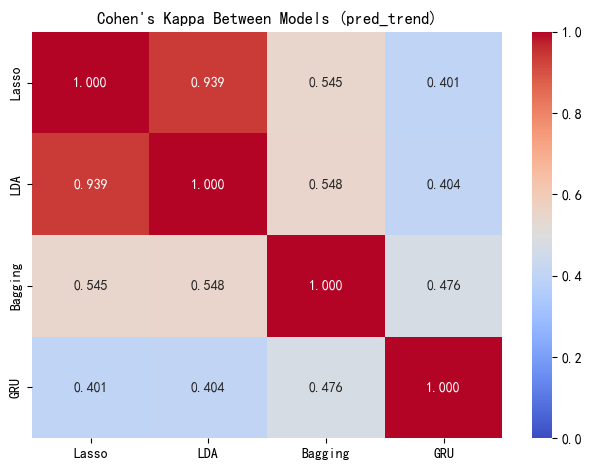

In [4]:
# Visualize the Kappa matrix as a heatmap
sns.heatmap(kappa_matrix.astype(float), annot=True, fmt='.3f', 
            cmap='coolwarm', vmin=0, vmax=1)
plt.title("Cohen's Kappa Between Models (pred_trend)")
plt.tight_layout()
plt.show()

In [5]:
# Average the predicted probabilities across the three models for the common timestamps
common_idx = df_lasso_5m.index.intersection(df_bagging_5m.index).intersection(df_gru_5m.index)
prob_cols = ['prob_down', 'prob_noise', 'prob_up']
prob_ensemble = (
    df_lasso_5m.loc[common_idx, prob_cols].values +
    df_bagging_5m.loc[common_idx, prob_cols].values +
    df_gru_5m.loc[common_idx, prob_cols].values
) / 3

# Create a new DataFrame to hold the ensemble probabilities and the corresponding close prices and true trends
df_ensemble_5m = pd.DataFrame(prob_ensemble, index=common_idx, columns=prob_cols)
df_ensemble_5m.insert(0, 'close', df_lasso_5m.loc[common_idx, 'close'])
df_ensemble_5m.insert(1, 'trend_5m', df_lasso_5m.loc[common_idx, 'trend_5m'])
df_ensemble_5m.insert(2, 'pred_trend', np.argmax(prob_ensemble, axis=1))

df_ensemble_5m.head()


,close,trend_5m,pred_trend,prob_down,prob_noise,prob_up
time,,,,,,
2025-01-23 03:06:00+00:00,30.6485,0,1,0.238957,0.483708,0.277336
2025-01-23 03:07:00+00:00,30.6480,0,1,0.157370,0.560927,0.281703
2025-01-23 03:08:00+00:00,30.6400,0,1,0.182448,0.545975,0.271577
2025-01-23 03:09:00+00:00,30.6345,1,1,0.189174,0.455101,0.355726
2025-01-23 03:10:00+00:00,30.6335,1,1,0.175104,0.468967,0.355929


In [8]:
ensemble_accuracy = accuracy_score(df_ensemble_5m['trend_5m'], df_ensemble_5m['pred_trend'])
ensemble_precision = precision_score(df_ensemble_5m['trend_5m'], df_ensemble_5m['pred_trend'], average='macro', zero_division=0)
ensemble_recall = recall_score(df_ensemble_5m['trend_5m'], df_ensemble_5m['pred_trend'], average='macro', zero_division=0)
ensemble_f1 = f1_score(df_ensemble_5m['trend_5m'], df_ensemble_5m['pred_trend'], average='macro', zero_division=0)
ensemble_log_loss = log_loss(df_ensemble_5m['trend_5m'], df_ensemble_5m[prob_cols], labels=[0, 1, 2])
ensemble_brier_score = np.mean(np.sum((label_binarize(df_ensemble_5m['trend_5m'], classes=[0, 1, 2]) - df_ensemble_5m[prob_cols].values) ** 2, axis=1))
ensemble_auc = roc_auc_score(label_binarize(df_ensemble_5m['trend_5m'], classes=[0, 1, 2]), df_ensemble_5m[prob_cols].values, multi_class='ovr')

print("=== Ensemble metrics summary (trend_5m) ===\n")
print(f"{'Ensemble':<20s} | "
      f"Accuracy={ensemble_accuracy:.4f}  "
      f"Precision={ensemble_precision:.4f}  "
      f"Recall={ensemble_recall:.4f}  "
      f"F1={ensemble_f1:.4f}  "
      f"Log Loss={ensemble_log_loss:.4f}  "
      f"Brier Score={ensemble_brier_score:.4f}  "
      f"ROC AUC={ensemble_auc:.4f}")            

=== Ensemble metrics summary (trend_5m) ===

Ensemble             | Accuracy=0.5119  Precision=0.4403  Recall=0.4256  F1=0.4097  Log Loss=0.9905  Brier Score=0.5898  ROC AUC=0.6534


In [54]:
df_ensemble_5m = df_ensemble_5m.iloc[::5].copy()
df_ensemble_5m.head()

,close,trend_5m,pred_trend,prob_down,prob_noise,prob_up
time,,,,,,
2025-01-23 03:06:00+00:00,30.64850,0,1,0.238957,0.483708,0.277336
2025-01-23 03:11:00+00:00,30.62350,1,1,0.200097,0.479420,0.320483
2025-01-23 03:16:00+00:00,30.62475,1,1,0.213510,0.482721,0.303770
2025-01-23 03:21:00+00:00,30.61725,1,2,0.274185,0.360697,0.365118
2025-01-23 03:26:00+00:00,30.61870,1,1,0.173667,0.564275,0.262058


In [59]:
# Constuct trading signals based on the ensemble's predicted class and probabilities
buys=((df_ensemble_5m['pred_trend'] == 2) & (df_ensemble_5m['prob_up'] >= 0.5)) # enter when model predicts strong uptrend
sells=((df_ensemble_5m['pred_trend'] == 0) & (df_ensemble_5m['prob_down'] >= 0.5)) # exit when model predicts strong downtrend

pf_xag_ensemble = vbt.Portfolio.from_signals(df_ensemble_5m['close'], entries=buys, exits=sells, fees=0.0003, slippage=0.0001, freq='1min')
pf_xag_ensemble.stats()

Start                         2025-01-23 03:06:00+00:00
End                           2026-01-30 10:05:00+00:00
Period                                 49 days 16:40:00
Start Value                                       100.0
End Value                                    186.395692
Total Return [%]                              86.395692
Benchmark Return [%]                         221.133661
Max Gross Exposure [%]                            100.0
Total Fees Paid                               13.914585
Max Drawdown [%]                              21.119085
Max Drawdown Duration                   8 days 07:03:00
Total Trades                                        149
Total Closed Trades                                 148
Total Open Trades                                     1
Open Trade PnL                                -0.074564
Win Rate [%]                                  58.783784
Best Trade [%]                                12.742866
Worst Trade [%]                               -7

# 2. XAU

## 2.1 Data Cleaning

In [2]:
xau = pd.read_csv('data/COMMODITY/XAU_USD.csv', index_col=0)

print("raw data shape:", xau.shape)
print('\ncolumn names:', xau.columns.tolist())
print("\ndata types:\n", xau.dtypes)
print("\nfirt 5 rows:\n", xau.head())

raw data shape: (380347, 14)

column names: ['symbol', 'time', 'file_time', 'status', 'open_bid', 'high_bid', 'low_bid', 'close_bid', 'open_ask', 'high_ask', 'low_ask', 'close_ask', 'tick_cnt', 'time_frame']

data types:
 symbol         object
time           object
file_time       int64
status         object
open_bid      float64
high_bid      float64
low_bid       float64
close_bid     float64
open_ask      float64
high_ask      float64
low_ask       float64
close_ask     float64
tick_cnt        int64
time_frame     object
dtype: object

firt 5 rows:
     symbol                       time     file_time status  open_bid  \
0  XAU_USD  2025-01-01 23:04:00+00:00  202501012304    NaN  2625.070   
1  XAU_USD  2025-01-01 23:05:00+00:00  202501012305    NaN  2625.115   
2  XAU_USD  2025-01-01 23:06:00+00:00  202501012306    NaN  2625.140   
3  XAU_USD  2025-01-01 23:07:00+00:00  202501012307    NaN  2625.290   
4  XAU_USD  2025-01-01 23:08:00+00:00  202501012308    NaN  2625.125   

   high_

In [3]:
## Set `time` as the index
xau['time'] = pd.to_datetime(xau['time'])
xau.set_index('time', inplace=True)
print(f'[1] Set `time` as index')

## Drop rows with missing `status`
before = len(xau)
xau = xau.dropna(subset=['status'])
print(f'[2] Dropped {before - len(xau)} rows with missing `status`')

## Drop unnecessary columns
xau = xau.drop(columns=['symbol', 'file_time', 'status', 'time_frame'])
print(f'[3] Dropped columns: symbol, file_time, status, time_frame')

## Create mid price for open, high, low, and close
xau['open'] = (xau['open_bid'] + xau['open_ask']) / 2  # Open
xau['high'] = (xau['high_bid'] + xau['high_ask']) / 2  # High
xau['low'] = (xau['low_bid'] + xau['low_ask']) / 2  # Low
xau['close'] = (xau['close_bid'] + xau['close_ask']) / 2  # Close
xau['volume'] = np.log1p(xau['tick_cnt'])  # Log-transform volume
print(f'[4] Created mid prices for: open, high, low, close')

print(f'\nData shape after preprocessing: {xau.shape}')
print(f'Time range: {xau.index.min().date()} ~ {xau.index.max().date()}')
print(f'Total trading days: {xau.index.normalize().nunique()}')

[1] Set `time` as index
[2] Dropped 19337 rows with missing `status`
[3] Dropped columns: symbol, file_time, status, time_frame
[4] Created mid prices for: open, high, low, close

Data shape after preprocessing: (361010, 14)
Time range: 2025-01-21 ~ 2026-01-30
Total trading days: 321


=== Key features descriptive statistics ===
              open         high          low        close       volume
count  361010.0000  361010.0000  361010.0000  361010.0000  361010.0000
mean     3583.8197    3584.5550    3583.0716    3583.8256       4.6953
std       562.2436     562.5444     561.9269     562.2457       0.7301
min      2730.6600    2731.9250    2730.5500    2730.6250       0.6931
25%      3240.1562    3240.9762    3239.3813    3240.1500       4.3307
50%      3367.2525    3367.7050    3366.7550    3367.2425       4.7449
75%      4048.9650    4050.1325    4047.8375    4048.9900       5.0814
max      5593.4250    5602.2250    5591.2850    5593.5700       8.4249


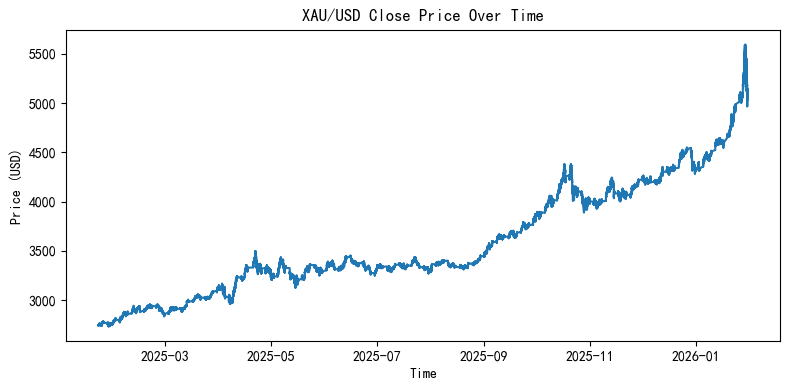

Data cleaning and EDA completed. Ready for feature engineering...


In [4]:
key_cols = ['open', 'high', 'low', 'close', 'volume']
print("=== Key features descriptive statistics ===")
print(xau[key_cols].describe().round(4))

## plot close price over time
plt.figure(figsize=(8, 4))
plt.plot(xau.index, xau['close'])
plt.title('XAU/USD Close Price Over Time')
plt.xlabel('Time')
plt.ylabel('Price (USD)')
plt.tight_layout()
plt.show()
print('Data cleaning and EDA completed. Ready for feature engineering...')

## 2.2 Feature Engineering

In [ ]:
# define rolling window size
n = 10

In [6]:
# F01: Relative Bid-Ask Spread
xau['RS'] = (xau['close_ask'] - xau['close_bid']) / xau['close']
# Price-normalized spread enabling cross-sectional comparison. Negatively correlated with short-horizon returns; 
# widely used as a proxy for the liquidity risk premium.

# F02: Spread Change Z-Score
xau['SCZ'] = (xau['RS'] - xau['RS'].rolling(window=n).mean()) / xau['RS'].rolling(window=n).std()
# Captures sudden liquidity shocks. An abnormally wide spread often precedes large-order market impact; 
# used as a position-sizing or stop-loss trigger in execution models

# F03: Intrabar Spread Asymmetry
xau['ISA'] = ((xau['high_ask'] - xau['high_bid']) - (xau['low_ask'] - xau['low_bid']))/ xau['close']
# Measures within-bar spread imbalance between bid and ask sides. Positive values (ask-side expansion at highs) signal market stress; 
# negative values imply bid-side support.

In [7]:
#F04: Mid-Price Log Return
xau['MPR'] = np.log(xau['close'])-np.log(xau['close'].shift(n))
# Log return of the mid-price, eliminating single-sided quote noise. Short lookbacks (5–15 min) tend to mean-revert; 
# longer lookbacks (30–60 min) exhibit momentum persistence.

#F05: Intrabar Price Skewness
xau['IPS'] = (xau['close']-xau['open'])/(xau['high']-xau['low'])
# Analogous to Williams %R. Close near the bar's high (+1) signals bullish dominance; 
# near the low (−1) signals bearish dominance. Predictive of the next bar's direction.

#F06: Open-to-Close Gap
xau['OCG'] = (xau['open'] - xau['close'].shift(1)) / xau['close'].shift(1)
# Inter-bar mid-price gap between successive minutes. At high frequencies, gaps exhibit strong mean-reversion tendencies, 
# forming the basis of scalping and gap-fade strategies.

#F07: Range Expansion Ratio
xau['range'] = xau['high'] - xau['low']
xau['RER'] = xau['range'] / xau['range'].rolling(window=n).mean()
# RER > 1.5 often accompanies trend breakouts; RER < 0.5 indicates price compression (low-volatility regime), 
# frequently preceding explosive directional moves.

#F08: MA Spread / Crossover Signal
xau['MS'] = (xau['close'].rolling(window=5).mean()-xau['close'].rolling(window=20).mean())/xau['close'].rolling(window=20).mean()
# Measures short-term momentum relative to a longer-term trend. Positive values indicate bullish crossover;
# negative values indicate bearish crossover. The magnitude of MS can be used to gauge momentum strength.

#F09: Price Relative to MA20 (Mean-Reversion Signal)
xau['MR'] = (xau['close'] - xau['close'].rolling(window=20).mean()) / xau['close'].rolling(window=20).mean()
# Measures how far the current price deviates from its 20-minute moving average. Extreme positive values suggest overextension and potential mean-reversion;
# extreme negative values suggest overselling and potential mean-reversion.

In [8]:
#F10: Volume Density Ratio
xau['VDR'] = xau['volume'] / xau['volume'].rolling(window=n).mean()
# Normalizes current volume activity against its rolling average. VDR significantly above 1 indicates unusual order flow 
# — strongly associated with institutional activity and trend initiation.

#F11: Price-Volume Correlation
xau['delta']=xau['close'].diff()
xau['PVC'] = xau['delta'].rolling(window=n).corr(xau['volume'])
# Rolling correlation between mid-price changes and volume counts. Positive correlation confirms volume-price agreement (trend valid); 
# negative divergence signals potential reversal.

#F12: Volume-Weighted Mid Deviation
xau['amount'] = xau['volume'] * xau['close']
xau['VWAP'] = xau['amount'].rolling(window=n).sum() / xau['volume'].rolling(window=n).sum()
xau['VWMD'] = (xau['close'] - xau['VWAP'])/xau['VWAP']
# VWAP analog using volume counts as volume proxy. Deviation from volume-weighted average is a mean-reversion signal; 
# persistent one-sided deviation indicates informed order flow.

#F13: Volume Acceleration
xau['VACC_R'] = (xau['volume'] - xau['volume'].shift(1))/xau['volume'].shift(1)
# First difference of volume counts — an activity acceleration indicator. Sustained volume acceleration is a hallmark of 
# algorithmic order slicing (TWAP/VWAP execution), predicting short-term price continuation.

In [9]:
## F14:Parkinson Volatility
xau['Parkinson']=np.log(xau['high']/xau['low'])**2
xau['PV'] = np.sqrt(xau['Parkinson'].rolling(window=n).mean()/(4*np.log(2)))
# Efficient range-based volatility estimator utilizing high and low prices. Reduces estimator variance by 
# ~5× versus close-to-close estimators — essential for noisy minute-level data.

# F15: Garman-Klass Volatility
xau['GKV'] = 0.5 * np.log((xau['high']/xau['low'])**2) - (2*np.log(2)-1) * np.log((xau['close']/xau['open'])**2)
# Optimal unbiased estimator exploiting all four OHLC prices. Compute independently on bid and ask series and average. 
# Outperforms Parkinson by further incorporating open-close information.

#F16: Volatility Regime Ratio
short = 5
long = 60
xau['VRR'] = xau['PV'].rolling(window=short).mean() / xau['PV'].rolling(window=long).mean()
# Short-to-long realized volatility ratio. VRR > 1 flags abnormal near-term turbulence (risk-off signal); 
# rising VRR trend often precedes large directional breaks. Central to regime detection.

#F17: Bid-Ask Volatility Asymmetry
xau['BVA'] = xau['close_bid'].rolling(window=n).std() / xau['close_ask'].rolling(window=n).std()
# Volatility differential between bid and ask quote series. Positive BVA (bid more volatile) implies elevated buy-side pressure; 
# negative implies sell-side dominance. Reflects structural order book imbalance.

In [10]:
#F18: Roll Implied Spread
xau['delta_lag1']=xau['delta'].shift(1)
xau['cov'] = xau['delta'].rolling(window=n).cov(xau['delta_lag1'])
xau['RIS']= 2 * np.sqrt(np.maximum(-xau['cov'], 0))
# Classic Roll (1984) estimator that recovers the implicit spread from the serial covariance of mid-price changes. 
# Negative covariance is the microstructure fingerprint of the bid-ask bounce.

#F19: Kyle's Lambda (Price Impact)
xau['OF'] = np.sign(xau['delta']) * xau['volume']
cov_xy = xau['delta'].rolling(window=n).cov(xau['OF'])
var_x = xau['OF'].rolling(window=n).var()
xau['KL'] = cov_xy / var_x
# Kyle (1985) price impact coefficient estimated with volume as an order flow proxy. 
# λ̂ measures per-unit flow impact on price — a direct gauge of information asymmetry and market depth.

#F20: Amihud Illiquidity Ratio
xau['ILLIQ'] = abs(xau['delta']) / xau['volume']
xau['AIR'] = xau['ILLIQ'].rolling(window=n).mean()
# Amihud (2002) illiquidity ratio adapted to minute bars 
# Higher AIR means greater price impact per unit of order flow — illiquidity risk premium proxy.

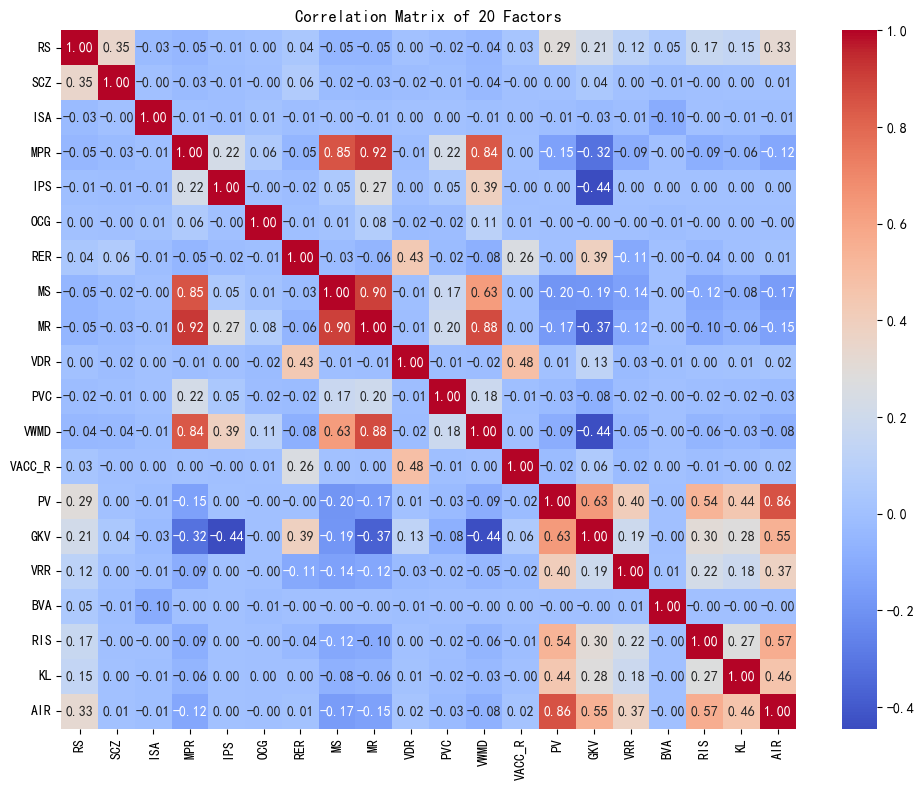

In [11]:
# factor correlation heatmap
plt.figure(figsize=(10, 8))
BASE_FACTORS = ['RS', 'SCZ', 'ISA', 'MPR', 'IPS', 'OCG', 'RER', 'MS', 'MR', 'VDR', 'PVC', 'VWMD', 'VACC_R', 'PV', 'GKV', 'VRR', 'BVA', 'RIS', 'KL', 'AIR']
corr_matrix = xau[BASE_FACTORS].corr()
sns.heatmap(corr_matrix, annot=True, fmt=".2f", cmap='coolwarm', cbar=True)
plt.title('Correlation Matrix of 20 Factors')
plt.tight_layout()
plt.show()

In [12]:
# Factor addition: time features, and volatility regime features
def add_time_features(df):
    out = df.copy()
    idx = out.index

    # Intraday time features
    # Cyclical encoding
    out["hour_sin"] = np.sin(2 * np.pi * idx.hour / 24)
    out["hour_cos"] = np.cos(2 * np.pi * idx.hour / 24)
    out["minute_sin"] = np.sin(2 * np.pi * idx.minute / 60)
    out["minute_cos"] = np.cos(2 * np.pi * idx.minute / 60)

    # Session flags
    out["is_asia_session"] = ((idx.hour >= 0) & (idx.hour < 8)).astype(int)
    out["is_europe_session"] = ((idx.hour >= 8) & (idx.hour < 16)).astype(int)
    out["is_us_session"] = ((idx.hour >= 13) & (idx.hour < 21)).astype(int)

    return out

def add_regime_features(df):
    out = df.copy()

    # Volatility regime features
    out['ret1'] = out["close"].pct_change(1)
    out["rv20"] = out["ret1"].rolling(20).std()

    q_low = out["rv20"].rolling(500).quantile(0.33)
    q_high = out["rv20"].rolling(500).quantile(0.66)

    out["regime_low_vol"] = (out["rv20"] <= q_low).astype(int)
    out["regime_high_vol"] = (out["rv20"] >= q_high).astype(int)

    return out

# Apply feature expansion
xau = add_time_features(xau)
xau = add_regime_features(xau)

TEST_FACTORS = BASE_FACTORS+['hour_sin','hour_cos','minute_sin','minute_cos','is_asia_session','is_europe_session','is_us_session','regime_low_vol', 'regime_high_vol']

## 2.3 Factor Testing

In [13]:
# Calculate forward returns for 5min, 10min, 20min, and 50min using log returns for better stability and interpretability
xau['ret_5m'] = np.log(xau['close'].shift(-5) / xau['close'])
xau['ret_10m'] = np.log(xau['close'].shift(-10) / xau['close'])
xau['ret_20m'] = np.log(xau['close'].shift(-20) / xau['close'])
xau['ret_50m'] = np.log(xau['close'].shift(-50) / xau['close'])

## Drop rows with NaN values
xau = xau.dropna(subset=['ret_5m', 'ret_10m', 'ret_20m', 'ret_50m'])
print("Forward return calculation completed")
print(xau[['ret_5m', 'ret_10m', 'ret_20m', 'ret_50m']].describe().round(4))

Forward return calculation completed
            ret_5m      ret_10m      ret_20m      ret_50m
count  360960.0000  360960.0000  360960.0000  360960.0000
mean        0.0000       0.0000       0.0000       0.0001
std         0.0008       0.0011       0.0015       0.0025
min        -0.0430      -0.0394      -0.0572      -0.0740
25%        -0.0003      -0.0004      -0.0006      -0.0009
50%         0.0000       0.0000       0.0000       0.0001
75%         0.0003       0.0005       0.0007       0.0012
max         0.0154       0.0176       0.0208       0.0372


In [14]:
## generate trend labels with different thresholds for different horizons
thresholds = {
    'ret_5m': 0.0003,   # ~0.03% move in 5 minutes
    'ret_10m': 0.0004,  # ~0.04% move in 10 minutes
    'ret_20m': 0.0006,   # ~0.06% move in 20 minutes
    'ret_50m': 0.0009   # ~0.09%    move in 50 minutes
}
    
xau['trend_5m'] = np.where(xau['ret_5m'] > thresholds['ret_5m'], 2, np.where(xau['ret_5m'] < -thresholds['ret_5m'], 0, 1))
xau['trend_10m'] = np.where(xau['ret_10m'] > thresholds['ret_10m'], 2, np.where(xau['ret_10m'] < -thresholds['ret_10m'], 0, 1))
xau['trend_20m'] = np.where(xau['ret_20m'] > thresholds['ret_20m'], 2, np.where(xau['ret_20m'] < -thresholds['ret_20m'], 0, 1))
xau['trend_50m'] = np.where(xau['ret_50m'] > thresholds['ret_50m'], 2, np.where(xau['ret_50m'] < -thresholds['ret_50m'], 0, 1))

In [15]:
# ──────────────────────────────────────────────────────────────────
# IC testing：every n-minute period Pearson IC 和 Rank IC
# ──────────────────────────────────────────────────────────────────
def compute_ic_series(df, factor_col, ret_col, n):
    """every n-minute period compute Pearson IC and Rank IC(Spearman)"""
    ic_list = []
    for i in range(0, len(df) - n, n):
        factor_values = df[factor_col].iloc[i:i+n]
        returns = df[ret_col].iloc[i:i+n]
        if len(factor_values) > 1 and len(returns) > 1:
            pearson_ic = factor_values.corr(returns)
            rank_ic, _ = spearmanr(factor_values, returns)
            ic_list.append({'time': df.index[i], 'IC': pearson_ic, 'RankIC': rank_ic})
    return pd.DataFrame(ic_list).set_index("time")

period = 600
# Compute all factors'IC to 5-minute future return
print("=== IC testing result summary (ret_5m) ===\n")
for fac in TEST_FACTORS:
    ic_s = compute_ic_series(xau, fac, 'ret_5m', period)
    ic_mean   = ic_s['IC'].mean()
    ic_std    = ic_s['IC'].std()
    icir      = ic_mean / ic_std if ic_std > 0 else 0
    rank_mean = ic_s['RankIC'].mean()
    rank_ir   = rank_mean / ic_s['RankIC'].std() if ic_s['RankIC'].std() > 0 else 0
    pos_pct   = (ic_s['IC'] > 0).mean() * 100
    print(f"{fac:20s} | IC={ic_mean:+.4f}  IC_IR={icir:+.3f}  "
          f"RankIC={rank_mean:+.4f}  RankIR={rank_ir:+.3f}  Positive IC percentage={pos_pct:.1f}%")

=== IC testing result summary (ret_5m) ===

RS                   | IC=+0.0138  IC_IR=+0.179  RankIC=+0.0123  RankIR=+0.183  Positive IC percentage=52.7%
SCZ                  | IC=+0.0038  IC_IR=+0.067  RankIC=+0.0021  RankIR=+0.041  Positive IC percentage=52.2%
ISA                  | IC=+0.0070  IC_IR=+0.116  RankIC=+0.0093  RankIR=+0.192  Positive IC percentage=52.9%
MPR                  | IC=-0.0256  IC_IR=-0.260  RankIC=-0.0323  RankIR=-0.405  Positive IC percentage=36.8%
IPS                  | IC=-0.0134  IC_IR=-0.329  RankIC=-0.0186  RankIR=-0.468  Positive IC percentage=36.6%
OCG                  | IC=-0.0042  IC_IR=-0.080  RankIC=-0.0022  RankIR=-0.050  Positive IC percentage=48.4%
RER                  | IC=+0.0064  IC_IR=+0.112  RankIC=+0.0053  RankIR=+0.112  Positive IC percentage=54.1%
MS                   | IC=-0.0217  IC_IR=-0.217  RankIC=-0.0316  RankIR=-0.380  Positive IC percentage=38.3%
MR                   | IC=-0.0323  IC_IR=-0.330  RankIC=-0.0395  RankIR=-0.491  Posi

In [16]:
# Compute all factors'IC to 10-minute future return
print("=== IC testing result summary (ret_10m) ===\n")
for fac in TEST_FACTORS:
    ic_s = compute_ic_series(xau, fac, 'ret_10m', period)
    ic_mean   = ic_s['IC'].mean()
    ic_std    = ic_s['IC'].std()
    icir      = ic_mean / ic_std if ic_std > 0 else 0
    rank_mean = ic_s['RankIC'].mean()
    rank_ir   = rank_mean / ic_s['RankIC'].std() if ic_s['RankIC'].std() > 0 else 0
    pos_pct   = (ic_s['IC'] > 0).mean() * 100
    print(f"{fac:20s} | IC={ic_mean:+.4f}  IC_IR={icir:+.3f}  "
          f"RankIC={rank_mean:+.4f}  RankIR={rank_ir:+.3f}  Positive IC percentage={pos_pct:.1f}%")

=== IC testing result summary (ret_10m) ===

RS                   | IC=+0.0145  IC_IR=+0.163  RankIC=+0.0155  RankIR=+0.188  Positive IC percentage=54.4%
SCZ                  | IC=+0.0027  IC_IR=+0.057  RankIC=+0.0019  RankIR=+0.039  Positive IC percentage=51.9%
ISA                  | IC=+0.0064  IC_IR=+0.102  RankIC=+0.0101  RankIR=+0.187  Positive IC percentage=52.2%
MPR                  | IC=-0.0275  IC_IR=-0.231  RankIC=-0.0368  RankIR=-0.373  Positive IC percentage=37.8%
IPS                  | IC=-0.0132  IC_IR=-0.323  RankIC=-0.0198  RankIR=-0.509  Positive IC percentage=36.8%
OCG                  | IC=-0.0042  IC_IR=-0.084  RankIC=-0.0022  RankIR=-0.051  Positive IC percentage=47.1%
RER                  | IC=+0.0064  IC_IR=+0.118  RankIC=+0.0064  RankIR=+0.138  Positive IC percentage=56.2%
MS                   | IC=-0.0284  IC_IR=-0.221  RankIC=-0.0379  RankIR=-0.348  Positive IC percentage=39.4%
MR                   | IC=-0.0379  IC_IR=-0.302  RankIC=-0.0467  RankIR=-0.443  Pos

In [17]:
# Compute all factors'IC to 20-minute future return
print("=== IC testing result summary (ret_20m) ===\n")
for fac in TEST_FACTORS:
    ic_s = compute_ic_series(xau, fac, 'ret_20m', period)
    ic_mean   = ic_s['IC'].mean()
    ic_std    = ic_s['IC'].std()
    icir      = ic_mean / ic_std if ic_std > 0 else 0
    rank_mean = ic_s['RankIC'].mean()
    rank_ir   = rank_mean / ic_s['RankIC'].std() if ic_s['RankIC'].std() > 0 else 0
    pos_pct   = (ic_s['IC'] > 0).mean() * 100
    print(f"{fac:20s} | IC={ic_mean:+.4f}  IC_IR={icir:+.3f}  "
          f"RankIC={rank_mean:+.4f}  RankIR={rank_ir:+.3f}  Positive IC percentage={pos_pct:.1f}%")

=== IC testing result summary (ret_20m) ===

RS                   | IC=+0.0139  IC_IR=+0.130  RankIC=+0.0200  RankIR=+0.189  Positive IC percentage=52.9%
SCZ                  | IC=+0.0035  IC_IR=+0.069  RankIC=+0.0020  RankIR=+0.047  Positive IC percentage=52.2%
ISA                  | IC=+0.0050  IC_IR=+0.077  RankIC=+0.0083  RankIR=+0.144  Positive IC percentage=49.4%
MPR                  | IC=-0.0414  IC_IR=-0.322  RankIC=-0.0421  RankIR=-0.392  Positive IC percentage=37.3%
IPS                  | IC=-0.0139  IC_IR=-0.338  RankIC=-0.0210  RankIR=-0.542  Positive IC percentage=35.8%
OCG                  | IC=-0.0035  IC_IR=-0.076  RankIC=-0.0034  RankIR=-0.078  Positive IC percentage=47.3%
RER                  | IC=+0.0032  IC_IR=+0.074  RankIC=+0.0020  RankIR=+0.051  Positive IC percentage=52.1%
MS                   | IC=-0.0447  IC_IR=-0.307  RankIC=-0.0449  RankIR=-0.359  Positive IC percentage=37.8%
MR                   | IC=-0.0512  IC_IR=-0.357  RankIC=-0.0520  RankIR=-0.425  Pos

In [18]:
# Compute all factors'IC to 50-minute future return
print("=== IC testing result summary (ret_50m) ===\n")
for fac in TEST_FACTORS:
    ic_s = compute_ic_series(xau, fac, 'ret_50m', period)
    ic_mean   = ic_s['IC'].mean()
    ic_std    = ic_s['IC'].std()
    icir      = ic_mean / ic_std if ic_std > 0 else 0
    rank_mean = ic_s['RankIC'].mean()
    rank_ir   = rank_mean / ic_s['RankIC'].std() if ic_s['RankIC'].std() > 0 else 0
    pos_pct   = (ic_s['IC'] > 0).mean() * 100
    print(f"{fac:20s} | IC={ic_mean:+.4f}  IC_IR={icir:+.3f}  "
          f"RankIC={rank_mean:+.4f}  RankIR={rank_ir:+.3f}  Positive IC percentage={pos_pct:.1f}%")

=== IC testing result summary (ret_50m) ===

RS                   | IC=+0.0185  IC_IR=+0.135  RankIC=+0.0280  RankIR=+0.200  Positive IC percentage=54.6%
SCZ                  | IC=+0.0022  IC_IR=+0.046  RankIC=-0.0001  RankIR=-0.002  Positive IC percentage=50.1%
ISA                  | IC=+0.0052  IC_IR=+0.077  RankIC=+0.0073  RankIR=+0.114  Positive IC percentage=51.4%
MPR                  | IC=-0.0660  IC_IR=-0.523  RankIC=-0.0615  RankIR=-0.554  Positive IC percentage=28.8%
IPS                  | IC=-0.0188  IC_IR=-0.482  RankIC=-0.0239  RankIR=-0.636  Positive IC percentage=29.5%
OCG                  | IC=-0.0049  IC_IR=-0.107  RankIC=-0.0041  RankIR=-0.089  Positive IC percentage=45.4%
RER                  | IC=+0.0039  IC_IR=+0.121  RankIC=+0.0020  RankIR=+0.064  Positive IC percentage=54.2%
MS                   | IC=-0.0765  IC_IR=-0.513  RankIC=-0.0708  RankIR=-0.525  Positive IC percentage=29.0%
MR                   | IC=-0.0802  IC_IR=-0.542  RankIC=-0.0747  RankIR=-0.564  Pos

In [20]:
# Factor expansion: add lag terms, change terms to high RankIC factors
def add_factor_transforms(df, factor_cols, lags=(1, 5, 20)):
    out = df.copy()

    for f in factor_cols:
        for l in lags:
            out[f"{f}_lag{l}"] = out[f].shift(l)          # 1) Lag features: capture persistence
            out[f"{f}_ret{l}"] = out[f].pct_change(l)     # 2) Change features: capture factor momentum
        
    return out

xau = add_factor_transforms(xau, BASE_FACTORS, lags=(1, 5, 20))
FACTORS_EXPANDED = TEST_FACTORS + xau.columns.tolist()[-120:]

## 2.4 Model Evaluation

In [ ]:
from sklearn.preprocessing import StandardScaler
from sklearn.preprocessing import label_binarize
from sklearn.decomposition import PCA
from sklearn.metrics import (accuracy_score, precision_score, recall_score, f1_score, log_loss, roc_auc_score)

def clean_X(X_train_df, X_val_df):
    # 1) inf -> nan
    X_train = X_train_df.replace([np.inf, -np.inf], np.nan).copy()
    X_val = X_val_df.replace([np.inf, -np.inf], np.nan).copy()

    # 2) use training set's μ±3σ to clip extreme values in both training and validation sets
    mu = X_train.mean()
    sigma = X_train.std()
    X_train = X_train.clip(lower=mu - 3 * sigma, upper=mu + 3 * sigma, axis=1)
    X_val = X_val.clip(lower=mu - 3 * sigma, upper=mu + 3 * sigma, axis=1)

    # 3) use training set's median to fill missing values in both training and validation sets
    med = X_train.median()
    X_train = X_train.fillna(med)
    X_val = X_val.fillna(med)

    # 4) after clipping and filling, if there are still nan values, replace them with 0
    X_train = X_train.replace(np.nan, 0.0)
    X_val = X_val.replace(np.nan, 0.0)

    return X_train.values, X_val.values

def rolling_backtest(df,factor_cols,target_col,model,
                     training_size,embargo,validation_size,step_size,
                     use_pca=False,pca_keep=0.8):
    """Rolling window backtest for classification model"""
    classification_metrics = []
    df_list = []

    for start in tqdm(range(0, len(df) - training_size - embargo - validation_size+1, step_size)):
        train_start = start
        train_end = start + training_size
        val_start = train_end + embargo
        val_end = val_start + validation_size
        
        train_df = df.iloc[train_start:train_end].copy()
        val_df = df.iloc[val_start:val_end].copy()

        X_train_df = train_df[factor_cols]
        X_val_df = val_df[factor_cols]
        y_train = train_df[target_col].values
        y_val = val_df[target_col].values

        # Step 1: data cleaning for features
        X_train, X_val = clean_X(X_train_df, X_val_df)

        # Step 2: standardize features using training set's parameters
        scaler = StandardScaler()
        X_train = scaler.fit_transform(X_train)
        X_val = scaler.transform(X_val)

        # Step 3(Optional): dimensionality reduction with PCA (fit on training set only)
        if use_pca:
            pca = PCA(n_components=pca_keep, svd_solver='full')  # retain specified percentage of the variance
            X_train = pca.fit_transform(X_train)
            X_val = pca.transform(X_val)

        model.fit(X_train, y_train)
        pred_trend = model.predict(X_val)  # predicted class labels
        pred_proba = model.predict_proba(X_val)  # predicted probabilities for each class
        y_onehot = label_binarize(y_val, classes=[0, 1, 2])
        val_df['pred_trend'] = pred_trend  # predicted class labels
        val_df['prob_down'] = pred_proba[:, 0]  # probability of down class
        val_df['prob_noise'] = pred_proba[:, 1]  # probability of noise class
        val_df['prob_up'] = pred_proba[:, 2]  # probability of positive class

        # append the validation DataFrame to the full DataFrame
        classification_metrics.append({
            'time': val_df.index[0],
            'accuracy': accuracy_score(y_val, pred_trend),
            'precision': precision_score(y_val, pred_trend, average='macro', zero_division=0),
            'recall': recall_score(y_val, pred_trend, average='macro', zero_division=0),
            'f1': f1_score(y_val, pred_trend, average='macro', zero_division=0),
            'log_loss': log_loss(y_val, pred_proba, labels=[0, 1, 2]),
            'brier_score': np.mean(np.sum((y_onehot - pred_proba) ** 2, axis=1)),
            'roc_auc': roc_auc_score(y_onehot, pred_proba, multi_class='ovr'),  # ROC AUC for multi-class classification
        })
        df_list.append(val_df[['close', target_col, 'pred_trend', 'prob_down', 'prob_noise', 'prob_up']])
    
    return pd.DataFrame(classification_metrics).set_index('time'), pd.concat(df_list)

# employ rolling window for training and validation
training_size = 1800  # training window size
validation_size = 200  # validation window size
step_size = 1800  # step size for rolling window

### 2.4.1 Logistic Regression 

In [21]:
from sklearn.linear_model import LogisticRegression
## Create different logistic regression models(plain, lasso, ridge, elasticnet) for comparison
logistic_models={
    'LR_plain': LogisticRegression(solver='lbfgs', max_iter=1000, random_state=42),
    'LR_lasso': LogisticRegression(penalty='l1', solver='saga', max_iter=1000, random_state=42),
    'LR_ridge': LogisticRegression(penalty='l2', solver='lbfgs', max_iter=1000, random_state=42),
    'LR_elasticnet': LogisticRegression(penalty='elasticnet', solver='saga', l1_ratio=0.5, max_iter=1000, random_state=42)
}

# Summarize metrics for logistic models on 5-minute future trend
print("=== Logistic Regression metrics summary (trend_5m) ===\n")
TARGET_COL = 'trend_5m'
embargo = 5
for name, model in logistic_models.items():
    df_metric, _ = rolling_backtest(xau, FACTORS_EXPANDED, TARGET_COL, model, training_size, embargo, validation_size, step_size, use_pca=True, pca_keep=0.8)
    acc_mean = df_metric['accuracy'].mean()
    prec_mean = df_metric['precision'].mean()
    rec_mean = df_metric['recall'].mean()
    f1_mean = df_metric['f1'].mean()
    log_loss_mean = df_metric['log_loss'].mean()
    brier_mean = df_metric['brier_score'].mean()
    auc_mean = df_metric['roc_auc'].mean()
    pca_tag = "(with PCA)  "
    model_name = f"{name} {pca_tag}"

    print(f"{model_name:30s} | Accuracy={acc_mean:.4f}  Precision={prec_mean:.4f}  "
            f"Recall={rec_mean:.4f}  F1={f1_mean:.4f}  Log Loss={log_loss_mean:.4f}  "
            f"Brier Score={brier_mean:.4f}  ROC AUC={auc_mean:.4f}")

=== Logistic Regression metrics summary (trend_5m) ===



100%|██████████| 200/200 [00:41<00:00,  4.79it/s]


LR_plain (with PCA)            | Accuracy=0.4761  Precision=0.3608  Recall=0.3472  F1=0.3121  Log Loss=1.0568  Brier Score=0.6296  ROC AUC=0.5322


100%|██████████| 200/200 [01:33<00:00,  2.13it/s]


LR_lasso (with PCA)            | Accuracy=0.4760  Precision=0.3556  Recall=0.3464  F1=0.3103  Log Loss=1.0541  Brier Score=0.6283  ROC AUC=0.5326


100%|██████████| 200/200 [00:40<00:00,  4.97it/s]


LR_ridge (with PCA)            | Accuracy=0.4761  Precision=0.3608  Recall=0.3472  F1=0.3121  Log Loss=1.0568  Brier Score=0.6296  ROC AUC=0.5322


100%|██████████| 200/200 [02:23<00:00,  1.40it/s]

LR_elasticnet (with PCA)       | Accuracy=0.4761  Precision=0.3569  Recall=0.3468  F1=0.3110  Log Loss=1.0554  Brier Score=0.6289  ROC AUC=0.5324


In [22]:
# Summarize metrics for logistic models on 10-minute future trend
print("=== Logistic Regression metrics summary (trend_10m) ===\n")
TARGET_COL = 'trend_10m'
embargo = 10
for name, model in logistic_models.items():
    df_metric, _ = rolling_backtest(xau, FACTORS_EXPANDED, TARGET_COL, model, training_size, embargo, validation_size, step_size, use_pca=True, pca_keep=0.8)
    acc_mean = df_metric['accuracy'].mean()
    prec_mean = df_metric['precision'].mean()
    rec_mean = df_metric['recall'].mean()
    f1_mean = df_metric['f1'].mean()
    log_loss_mean = df_metric['log_loss'].mean()
    brier_mean = df_metric['brier_score'].mean()
    auc_mean = df_metric['roc_auc'].mean()
    pca_tag = "(with PCA)  "
    model_name = f"{name} {pca_tag}"

    print(f"{model_name:30s} | Accuracy={acc_mean:.4f}  Precision={prec_mean:.4f}  "
            f"Recall={rec_mean:.4f}  F1={f1_mean:.4f}  Log Loss={log_loss_mean:.4f}  "
            f"Brier Score={brier_mean:.4f}  ROC AUC={auc_mean:.4f}")

=== Logistic Regression metrics summary (trend_10m) ===



100%|██████████| 200/200 [00:45<00:00,  4.43it/s]


LR_plain (with PCA)            | Accuracy=0.4549  Precision=0.3514  Recall=0.3498  F1=0.3136  Log Loss=1.0965  Brier Score=0.6530  ROC AUC=0.5254


100%|██████████| 200/200 [01:51<00:00,  1.80it/s]


LR_lasso (with PCA)            | Accuracy=0.4560  Precision=0.3518  Recall=0.3501  F1=0.3133  Log Loss=1.0931  Brier Score=0.6514  ROC AUC=0.5257


100%|██████████| 200/200 [00:40<00:00,  4.98it/s]


LR_ridge (with PCA)            | Accuracy=0.4549  Precision=0.3514  Recall=0.3498  F1=0.3136  Log Loss=1.0965  Brier Score=0.6530  ROC AUC=0.5254


100%|██████████| 200/200 [02:30<00:00,  1.33it/s]

LR_elasticnet (with PCA)       | Accuracy=0.4552  Precision=0.3521  Recall=0.3496  F1=0.3131  Log Loss=1.0947  Brier Score=0.6522  ROC AUC=0.5256


In [23]:
# Summarize metrics for logistic models on 20-minute future trend
print("=== Logistic Regression metrics summary (trend_20m) ===\n")
TARGET_COL = 'trend_20m'
embargo = 20
for name, model in logistic_models.items():
    df_metric, _ = rolling_backtest(xau, FACTORS_EXPANDED, TARGET_COL, model, training_size, embargo, validation_size, step_size, use_pca=True, pca_keep=0.8)
    acc_mean = df_metric['accuracy'].mean()
    prec_mean = df_metric['precision'].mean()
    rec_mean = df_metric['recall'].mean()
    f1_mean = df_metric['f1'].mean()
    log_loss_mean = df_metric['log_loss'].mean()
    brier_mean = df_metric['brier_score'].mean()
    auc_mean = df_metric['roc_auc'].mean()
    pca_tag = "(with PCA)  "
    model_name = f"{name} {pca_tag}"

    print(f"{model_name:30s} | Accuracy={acc_mean:.4f}  Precision={prec_mean:.4f}  "
            f"Recall={rec_mean:.4f}  F1={f1_mean:.4f}  Log Loss={log_loss_mean:.4f}  "
            f"Brier Score={brier_mean:.4f}  ROC AUC={auc_mean:.4f}")

=== Logistic Regression metrics summary (trend_20m) ===



100%|██████████| 200/200 [00:54<00:00,  3.68it/s]


LR_plain (with PCA)            | Accuracy=0.4633  Precision=0.3452  Recall=0.3512  F1=0.3057  Log Loss=1.1166  Brier Score=0.6581  ROC AUC=0.5246


100%|██████████| 200/200 [02:10<00:00,  1.54it/s]


LR_lasso (with PCA)            | Accuracy=0.4642  Precision=0.3425  Recall=0.3506  F1=0.3045  Log Loss=1.1125  Brier Score=0.6564  ROC AUC=0.5247


100%|██████████| 200/200 [00:43<00:00,  4.63it/s]


LR_ridge (with PCA)            | Accuracy=0.4633  Precision=0.3452  Recall=0.3512  F1=0.3057  Log Loss=1.1166  Brier Score=0.6581  ROC AUC=0.5246


100%|██████████| 200/200 [03:10<00:00,  1.05it/s]

LR_elasticnet (with PCA)       | Accuracy=0.4636  Precision=0.3438  Recall=0.3509  F1=0.3052  Log Loss=1.1145  Brier Score=0.6572  ROC AUC=0.5246


In [24]:
# Summarize metrics for logistic models on 50-minute future trend
print("=== Logistic Regression metrics summary (trend_50m) ===\n")
TARGET_COL = 'trend_50m'
embargo = 50
for name, model in logistic_models.items():
    df_metric, _ = rolling_backtest(xau, FACTORS_EXPANDED, TARGET_COL, model, training_size, embargo, validation_size, step_size, use_pca=True, pca_keep=0.8)
    acc_mean = df_metric['accuracy'].mean()
    prec_mean = df_metric['precision'].mean()
    rec_mean = df_metric['recall'].mean()
    f1_mean = df_metric['f1'].mean()
    log_loss_mean = df_metric['log_loss'].mean()
    brier_mean = df_metric['brier_score'].mean()
    auc_mean = df_metric['roc_auc'].mean()
    pca_tag = "(with PCA)  "
    model_name = f"{name} {pca_tag}"

    print(f"{model_name:30s} | Accuracy={acc_mean:.4f}  Precision={prec_mean:.4f}  "
            f"Recall={rec_mean:.4f}  F1={f1_mean:.4f}  Log Loss={log_loss_mean:.4f}  "
            f"Brier Score={brier_mean:.4f}  ROC AUC={auc_mean:.4f}")

=== Logistic Regression metrics summary (trend_50m) ===



100%|██████████| 200/200 [00:53<00:00,  3.76it/s]


LR_plain (with PCA)            | Accuracy=0.4114  Precision=0.3369  Recall=0.3441  F1=0.2803  Log Loss=1.2408  Brier Score=0.7171  ROC AUC=0.5227


100%|██████████| 200/200 [02:14<00:00,  1.48it/s]


LR_lasso (with PCA)            | Accuracy=0.4122  Precision=0.3377  Recall=0.3443  F1=0.2800  Log Loss=1.2344  Brier Score=0.7149  ROC AUC=0.5229


100%|██████████| 200/200 [00:52<00:00,  3.78it/s]


LR_ridge (with PCA)            | Accuracy=0.4114  Precision=0.3369  Recall=0.3441  F1=0.2803  Log Loss=1.2408  Brier Score=0.7171  ROC AUC=0.5227


100%|██████████| 200/200 [03:29<00:00,  1.05s/it]

LR_elasticnet (with PCA)       | Accuracy=0.4119  Precision=0.3370  Recall=0.3439  F1=0.2800  Log Loss=1.2375  Brier Score=0.7160  ROC AUC=0.5228


### 2.4.2 Generative Models

In [25]:
# test generative classifiers (Naive Bayes, LDA, QDA, KNN) on future trend prediction
from sklearn.naive_bayes import GaussianNB
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis, QuadraticDiscriminantAnalysis
from sklearn.neighbors import KNeighborsClassifier

generative_models = {
    'Naive Bayes': GaussianNB(),
    'LDA': LinearDiscriminantAnalysis(),
    'QDA': QuadraticDiscriminantAnalysis(reg_param=0.1),  # add small regularization to avoid singular covariance
    'KNN': KNeighborsClassifier(n_neighbors=5)
}

# Summarize metrics for generative models on 5-minute future trend
print("=== Generative model metrics summary (trend_5m) ===\n")
TARGET_COL = 'trend_5m'
embargo = 5
for name, model in generative_models.items():
    df_metric, _ = rolling_backtest(xau, FACTORS_EXPANDED, TARGET_COL, model, training_size, embargo, validation_size, step_size, use_pca=True, pca_keep=0.8)
    acc_mean = df_metric['accuracy'].mean()
    prec_mean = df_metric['precision'].mean()
    rec_mean = df_metric['recall'].mean()
    f1_mean = df_metric['f1'].mean()
    log_loss_mean = df_metric['log_loss'].mean()
    brier_mean = df_metric['brier_score'].mean()
    auc_mean = df_metric['roc_auc'].mean()
    pca_tag = "(with PCA)  "
    model_name = f"{name} {pca_tag}"

    print(f"{model_name:30s} | Accuracy={acc_mean:.4f}  Precision={prec_mean:.4f}  "
            f"Recall={rec_mean:.4f}  F1={f1_mean:.4f}  Log Loss={log_loss_mean:.4f}  "
            f"Brier Score={brier_mean:.4f}  ROC AUC={auc_mean:.4f}")

=== Generative model metrics summary (trend_5m) ===



100%|██████████| 200/200 [00:50<00:00,  3.99it/s]


Naive Bayes (with PCA)         | Accuracy=0.4422  Precision=0.3600  Recall=0.3517  F1=0.3267  Log Loss=1.4762  Brier Score=0.7354  ROC AUC=0.5271


100%|██████████| 200/200 [00:52<00:00,  3.78it/s]


LDA (with PCA)                 | Accuracy=0.4768  Precision=0.3643  Recall=0.3479  F1=0.3123  Log Loss=1.0546  Brier Score=0.6287  ROC AUC=0.5328


100%|██████████| 200/200 [00:57<00:00,  3.48it/s]


QDA (with PCA)                 | Accuracy=0.4133  Precision=0.3559  Recall=0.3530  F1=0.3363  Log Loss=2.8681  Brier Score=0.9111  ROC AUC=0.5221


100%|██████████| 200/200 [01:03<00:00,  3.15it/s]

KNN (with PCA)                 | Accuracy=0.4304  Precision=0.3468  Recall=0.3440  F1=0.3275  Log Loss=6.2963  Brier Score=0.7412  ROC AUC=0.5116


In [26]:
# Summarize metrics for generative models on 10-minute future trend
print("=== Generative model metrics summary (trend_10m) ===\n")
TARGET_COL = 'trend_10m'
embargo = 10
for name, model in generative_models.items():
    df_metric, _ = rolling_backtest(xau, FACTORS_EXPANDED, TARGET_COL, model, training_size, embargo, validation_size, step_size, use_pca=True, pca_keep=0.8)
    acc_mean = df_metric['accuracy'].mean()
    prec_mean = df_metric['precision'].mean()
    rec_mean = df_metric['recall'].mean()
    f1_mean = df_metric['f1'].mean()
    log_loss_mean = df_metric['log_loss'].mean()
    brier_mean = df_metric['brier_score'].mean()
    auc_mean = df_metric['roc_auc'].mean()
    pca_tag = "(with PCA)  "
    model_name = f"{name} {pca_tag}"

    print(f"{model_name:30s} | Accuracy={acc_mean:.4f}  Precision={prec_mean:.4f}  "
            f"Recall={rec_mean:.4f}  F1={f1_mean:.4f}  Log Loss={log_loss_mean:.4f}  "
            f"Brier Score={brier_mean:.4f}  ROC AUC={auc_mean:.4f}")

=== Generative model metrics summary (trend_10m) ===



100%|██████████| 200/200 [00:48<00:00,  4.16it/s]


Naive Bayes (with PCA)         | Accuracy=0.4140  Precision=0.3495  Recall=0.3438  F1=0.3162  Log Loss=1.5460  Brier Score=0.7652  ROC AUC=0.5178


100%|██████████| 200/200 [00:53<00:00,  3.74it/s]


LDA (with PCA)                 | Accuracy=0.4563  Precision=0.3546  Recall=0.3505  F1=0.3136  Log Loss=1.0919  Brier Score=0.6514  ROC AUC=0.5264


100%|██████████| 200/200 [00:56<00:00,  3.54it/s]


QDA (with PCA)                 | Accuracy=0.3942  Precision=0.3450  Recall=0.3442  F1=0.3235  Log Loss=3.0403  Brier Score=0.9519  ROC AUC=0.5143


100%|██████████| 200/200 [01:03<00:00,  3.13it/s]

KNN (with PCA)                 | Accuracy=0.4082  Precision=0.3397  Recall=0.3412  F1=0.3209  Log Loss=6.7716  Brier Score=0.7675  ROC AUC=0.5089


In [27]:
# Summarize metrics for generative models on 20-minute future trend
print("=== Generative model metrics summary (trend_20m) ===\n")
TARGET_COL = 'trend_20m'
embargo = 20
for name, model in generative_models.items():
    df_metric, _ = rolling_backtest(xau, FACTORS_EXPANDED, TARGET_COL, model, training_size, embargo, validation_size, step_size, use_pca=True, pca_keep=0.8)
    acc_mean = df_metric['accuracy'].mean()
    prec_mean = df_metric['precision'].mean()
    rec_mean = df_metric['recall'].mean()
    f1_mean = df_metric['f1'].mean()
    log_loss_mean = df_metric['log_loss'].mean()
    brier_mean = df_metric['brier_score'].mean()
    auc_mean = df_metric['roc_auc'].mean()
    pca_tag = "(with PCA)  "
    model_name = f"{name} {pca_tag}"

    print(f"{model_name:30s} | Accuracy={acc_mean:.4f}  Precision={prec_mean:.4f}  "
            f"Recall={rec_mean:.4f}  F1={f1_mean:.4f}  Log Loss={log_loss_mean:.4f}  "
            f"Brier Score={brier_mean:.4f}  ROC AUC={auc_mean:.4f}")

=== Generative model metrics summary (trend_20m) ===



100%|██████████| 200/200 [00:47<00:00,  4.18it/s]


Naive Bayes (with PCA)         | Accuracy=0.4292  Precision=0.3532  Recall=0.3503  F1=0.3147  Log Loss=1.6079  Brier Score=0.7708  ROC AUC=0.5199


100%|██████████| 200/200 [00:51<00:00,  3.88it/s]


LDA (with PCA)                 | Accuracy=0.4637  Precision=0.3474  Recall=0.3514  F1=0.3041  Log Loss=1.1111  Brier Score=0.6566  ROC AUC=0.5249


100%|██████████| 200/200 [00:56<00:00,  3.51it/s]


QDA (with PCA)                 | Accuracy=0.4041  Precision=0.3430  Recall=0.3414  F1=0.3141  Log Loss=3.1988  Brier Score=0.9509  ROC AUC=0.5130


100%|██████████| 200/200 [00:58<00:00,  3.44it/s]

KNN (with PCA)                 | Accuracy=0.4184  Precision=0.3407  Recall=0.3394  F1=0.3142  Log Loss=7.1525  Brier Score=0.7670  ROC AUC=0.5086


In [29]:
# Summarize metrics for generative models on 50-minute future trend
print("=== Generative model metrics summary (trend_50m) ===\n")
TARGET_COL = 'trend_50m'
embargo = 50
for name, model in generative_models.items():
    df_metric, _ = rolling_backtest(xau, FACTORS_EXPANDED, TARGET_COL, model, training_size, embargo, validation_size, step_size, use_pca=True, pca_keep=0.8)
    acc_mean = df_metric['accuracy'].mean()
    prec_mean = df_metric['precision'].mean()
    rec_mean = df_metric['recall'].mean()
    f1_mean = df_metric['f1'].mean()
    log_loss_mean = df_metric['log_loss'].mean()
    brier_mean = df_metric['brier_score'].mean()
    auc_mean = df_metric['roc_auc'].mean()
    pca_tag = "(with PCA)  "
    model_name = f"{name} {pca_tag}"

    print(f"{model_name:30s} | Accuracy={acc_mean:.4f}  Precision={prec_mean:.4f}  "
            f"Recall={rec_mean:.4f}  F1={f1_mean:.4f}  Log Loss={log_loss_mean:.4f}  "
            f"Brier Score={brier_mean:.4f}  ROC AUC={auc_mean:.4f}")

=== Generative model metrics summary (trend_50m) ===



100%|██████████| 200/200 [00:46<00:00,  4.34it/s]


Naive Bayes (with PCA)         | Accuracy=0.3847  Precision=0.3446  Recall=0.3462  F1=0.2882  Log Loss=1.8143  Brier Score=0.8354  ROC AUC=0.5189


100%|██████████| 200/200 [00:50<00:00,  3.93it/s]


LDA (with PCA)                 | Accuracy=0.4136  Precision=0.3387  Recall=0.3474  F1=0.2798  Log Loss=1.2320  Brier Score=0.7160  ROC AUC=0.5236


100%|██████████| 200/200 [00:54<00:00,  3.64it/s]


QDA (with PCA)                 | Accuracy=0.3841  Precision=0.3363  Recall=0.3381  F1=0.2905  Log Loss=3.7162  Brier Score=1.0088  ROC AUC=0.5106


100%|██████████| 200/200 [01:01<00:00,  3.24it/s]

KNN (with PCA)                 | Accuracy=0.3917  Precision=0.3426  Recall=0.3361  F1=0.2952  Log Loss=7.9329  Brier Score=0.8069  ROC AUC=0.5060


### 2.4.3 Tree-based Models

In [37]:
# test tree-based classifiers (Bagging, Random Forest, Gradient Boosting, XGBoost) on future trend prediction
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import BaggingClassifier, RandomForestClassifier
from lightgbm import LGBMClassifier
from xgboost import XGBClassifier

tree_models = {
    "Bagging": BaggingClassifier(
        estimator=DecisionTreeClassifier(max_depth=4, min_samples_leaf=8, random_state=42),
        n_estimators=100,
        max_samples=0.8,
        bootstrap=True,
        random_state=42,
        n_jobs=-1
    ),
    "Random Forest": RandomForestClassifier(
        n_estimators=100,
        max_depth=4,
        min_samples_leaf=8,
        max_features='sqrt',
        class_weight="balanced",
        random_state=42,
        n_jobs=-1
    ),
    "LightGBM": LGBMClassifier(
        n_estimators=100,
        max_depth=4,
        min_child_samples=8,
        learning_rate=0.1,
        subsample=0.8,
        random_state=42,
        n_jobs=-1,
        verbosity=-1
    ),
    "XGBoost": XGBClassifier(
        n_estimators=100,
        max_depth=4,
        learning_rate=0.1,
        subsample=0.8,
        random_state=42,
        eval_metric="logloss",
        n_jobs=-1
    )
}

In [38]:
# Summarize metrics for tree-based models on 5-minute future trend
print("=== Tree-based model metrics summary (trend_5m) ===\n")
TARGET_COL = 'trend_5m'
embargo = 5
for name, model in tree_models.items():
    df_metric, _ = rolling_backtest(xau, FACTORS_EXPANDED, TARGET_COL, model, training_size, embargo, validation_size, step_size, use_pca=False, pca_keep=0.8)
    acc_mean = df_metric['accuracy'].mean()
    prec_mean = df_metric['precision'].mean()
    rec_mean = df_metric['recall'].mean()
    f1_mean = df_metric['f1'].mean()
    log_loss_mean = df_metric['log_loss'].mean()
    brier_mean = df_metric['brier_score'].mean()
    auc_mean = df_metric['roc_auc'].mean()

    print(f"{name:20s} | Accuracy={acc_mean:.4f}  Precision={prec_mean:.4f}  "
            f"Recall={rec_mean:.4f}  F1={f1_mean:.4f}  Log Loss={log_loss_mean:.4f}  "
            f"Brier Score={brier_mean:.4f}  ROC AUC={auc_mean:.4f}")

=== Tree-based model metrics summary (trend_5m) ===



100%|██████████| 200/200 [02:46<00:00,  1.20it/s]


Bagging              | Accuracy=0.4909  Precision=0.3180  Recall=0.3473  F1=0.2897  Log Loss=1.0188  Brier Score=0.6091  ROC AUC=0.5428


100%|██████████| 200/200 [01:36<00:00,  2.08it/s]


Random Forest        | Accuracy=0.4253  Precision=0.3611  Recall=0.3600  F1=0.3294  Log Loss=1.0699  Brier Score=0.6464  ROC AUC=0.5370


100%|██████████| 200/200 [01:48<00:00,  1.84it/s]


LightGBM             | Accuracy=0.4625  Precision=0.3511  Recall=0.3495  F1=0.3245  Log Loss=1.1341  Brier Score=0.6662  ROC AUC=0.5279


100%|██████████| 200/200 [02:56<00:00,  1.13it/s]

XGBoost              | Accuracy=0.4699  Precision=0.3644  Recall=0.3513  F1=0.3239  Log Loss=1.0952  Brier Score=0.6491  ROC AUC=0.5326


In [39]:
# Summarize metrics for tree-based models on 10-minute future trend
print("=== Tree-based model metrics summary (trend_10m) ===\n")
TARGET_COL = 'trend_10m'
embargo = 10
for name, model in tree_models.items():
    df_metric, _ = rolling_backtest(xau, FACTORS_EXPANDED, TARGET_COL, model, training_size, embargo, validation_size, step_size, use_pca=False, pca_keep=0.8)
    acc_mean = df_metric['accuracy'].mean()
    prec_mean = df_metric['precision'].mean()
    rec_mean = df_metric['recall'].mean()
    f1_mean = df_metric['f1'].mean()
    log_loss_mean = df_metric['log_loss'].mean()
    brier_mean = df_metric['brier_score'].mean()
    auc_mean = df_metric['roc_auc'].mean()

    print(f"{name:20s} | Accuracy={acc_mean:.4f}  Precision={prec_mean:.4f}  "
            f"Recall={rec_mean:.4f}  F1={f1_mean:.4f}  Log Loss={log_loss_mean:.4f}  "
            f"Brier Score={brier_mean:.4f}  ROC AUC={auc_mean:.4f}")

=== Tree-based model metrics summary (trend_10m) ===



100%|██████████| 200/200 [02:44<00:00,  1.22it/s]


Bagging              | Accuracy=0.4699  Precision=0.3274  Recall=0.3523  F1=0.2962  Log Loss=1.0459  Brier Score=0.6277  ROC AUC=0.5323


100%|██████████| 200/200 [01:19<00:00,  2.52it/s]


Random Forest        | Accuracy=0.4042  Precision=0.3513  Recall=0.3584  F1=0.3210  Log Loss=1.0790  Brier Score=0.6531  ROC AUC=0.5307


100%|██████████| 200/200 [01:41<00:00,  1.98it/s]


LightGBM             | Accuracy=0.4407  Precision=0.3588  Recall=0.3541  F1=0.3252  Log Loss=1.1968  Brier Score=0.6997  ROC AUC=0.5307


100%|██████████| 200/200 [03:07<00:00,  1.07it/s]

XGBoost              | Accuracy=0.4465  Precision=0.3583  Recall=0.3545  F1=0.3228  Log Loss=1.1492  Brier Score=0.6799  ROC AUC=0.5319


In [40]:
# Summarize metrics for tree-based models on 20-minute future trend
print("=== Tree-based model metrics summary (trend_20m) ===\n")
TARGET_COL = 'trend_20m'
embargo = 20
for name, model in tree_models.items():
    df_metric, _ = rolling_backtest(xau, FACTORS_EXPANDED, TARGET_COL, model, training_size, embargo, validation_size, step_size, use_pca=False, pca_keep=0.8)
    acc_mean = df_metric['accuracy'].mean()
    prec_mean = df_metric['precision'].mean()
    rec_mean = df_metric['recall'].mean()
    f1_mean = df_metric['f1'].mean()
    log_loss_mean = df_metric['log_loss'].mean()
    brier_mean = df_metric['brier_score'].mean()
    auc_mean = df_metric['roc_auc'].mean()

    print(f"{name:20s} | Accuracy={acc_mean:.4f}  Precision={prec_mean:.4f}  "
            f"Recall={rec_mean:.4f}  F1={f1_mean:.4f}  Log Loss={log_loss_mean:.4f}  "
            f"Brier Score={brier_mean:.4f}  ROC AUC={auc_mean:.4f}")

=== Tree-based model metrics summary (trend_20m) ===



100%|██████████| 200/200 [02:50<00:00,  1.17it/s]


Bagging              | Accuracy=0.4683  Precision=0.3113  Recall=0.3457  F1=0.2826  Log Loss=1.0653  Brier Score=0.6386  ROC AUC=0.5254


100%|██████████| 200/200 [01:46<00:00,  1.88it/s]


Random Forest        | Accuracy=0.4008  Precision=0.3412  Recall=0.3529  F1=0.3044  Log Loss=1.0818  Brier Score=0.6552  ROC AUC=0.5255


100%|██████████| 200/200 [02:06<00:00,  1.58it/s]


LightGBM             | Accuracy=0.4420  Precision=0.3459  Recall=0.3520  F1=0.3104  Log Loss=1.2949  Brier Score=0.7303  ROC AUC=0.5255


100%|██████████| 200/200 [03:00<00:00,  1.11it/s]

XGBoost              | Accuracy=0.4468  Precision=0.3430  Recall=0.3512  F1=0.3066  Log Loss=1.2124  Brier Score=0.7038  ROC AUC=0.5281


In [41]:
# Summarize metrics for tree-based models on 50-minute future trend
print("=== Tree-based model metrics summary (trend_50m) ===\n")
TARGET_COL = 'trend_50m'
embargo = 50
for name, model in tree_models.items():
    df_metric, _ = rolling_backtest(xau, FACTORS_EXPANDED, TARGET_COL, model, training_size, embargo, validation_size, step_size, use_pca=False, pca_keep=0.8)
    acc_mean = df_metric['accuracy'].mean()
    prec_mean = df_metric['precision'].mean()
    rec_mean = df_metric['recall'].mean()
    f1_mean = df_metric['f1'].mean()
    log_loss_mean = df_metric['log_loss'].mean()
    brier_mean = df_metric['brier_score'].mean()
    auc_mean = df_metric['roc_auc'].mean()

    print(f"{name:20s} | Accuracy={acc_mean:.4f}  Precision={prec_mean:.4f}  "
            f"Recall={rec_mean:.4f}  F1={f1_mean:.4f}  Log Loss={log_loss_mean:.4f}  "
            f"Brier Score={brier_mean:.4f}  ROC AUC={auc_mean:.4f}")

=== Tree-based model metrics summary (trend_50m) ===



100%|██████████| 200/200 [02:52<00:00,  1.16it/s]


Bagging              | Accuracy=0.4272  Precision=0.3248  Recall=0.3557  F1=0.2786  Log Loss=1.2848  Brier Score=0.7084  ROC AUC=0.5319


100%|██████████| 200/200 [01:38<00:00,  2.03it/s]


Random Forest        | Accuracy=0.3660  Precision=0.3164  Recall=0.3408  F1=0.2649  Log Loss=1.1069  Brier Score=0.6725  ROC AUC=0.5245


100%|██████████| 200/200 [01:44<00:00,  1.92it/s]


LightGBM             | Accuracy=0.4084  Precision=0.3555  Recall=0.3518  F1=0.2908  Log Loss=1.5792  Brier Score=0.8270  ROC AUC=0.5375


100%|██████████| 200/200 [03:12<00:00,  1.04it/s]

XGBoost              | Accuracy=0.4108  Precision=0.3530  Recall=0.3538  F1=0.2898  Log Loss=1.4255  Brier Score=0.7914  ROC AUC=0.5344


### 2.4.4 Neural Network

In [42]:
# Import PyTorch for RNN model definition and training
import torch
import torch.nn as nn
from torch.utils.data import TensorDataset, DataLoader

class TrendGRU(nn.Module):
    """Single-layer GRU that maps a (batch, seq_len, 3) input to 3-class logits."""
    def __init__(self, input_size=3, hidden_size=12, dropout=0.1):
        super().__init__()
        # GRU recurrent layer: processes the 5-timestep sequence of (return, volume, volatility)
        self.gru = nn.GRU(input_size=input_size, hidden_size=hidden_size,
                          num_layers=1, batch_first=True)
        # Dropout applied to the last hidden state before the classification head
        self.dropout = nn.Dropout(dropout)
        # Linear head: maps hidden representation to 3 class logits (down=0, noise=1, up=2)
        self.fc = nn.Linear(hidden_size, 3)

    def forward(self, x):
        # x: (batch, seq_len, input_size)
        _, h_n = self.gru(x)           # h_n: (num_layers=1, batch, hidden_size)
        h_last = h_n.squeeze(0)        # (batch, hidden_size) -- last timestep hidden state
        return self.fc(self.dropout(h_last))  # (batch, 3) raw logits
    
def build_sequences(X_scaled_np, y_np, seq_len):
    """Build overlapping sequences of length seq_len from scaled feature array.

    Must be called AFTER scaling so no leakage occurs.
    Lags look backward only (rows i-seq_len+1 to i), never forward.

    Args:
        X_scaled_np : np.ndarray, shape (N, 3) -- scaled [MPR, volume, PV]
        y_np        : np.ndarray, shape (N,)   -- integer class labels
        seq_len     : int, number of timesteps per sample (default 5 = current + 4 lags)

    Returns:
        X_seq : torch.FloatTensor, shape (N - seq_len + 1, seq_len, 3)
        y_seq : torch.LongTensor,  shape (N - seq_len + 1,)
    """
    X_list, y_list = [], []
    for i in range(seq_len - 1, len(X_scaled_np)):
        # Window: rows [i - seq_len + 1, ..., i] -- shape (seq_len, 3)
        X_list.append(X_scaled_np[i - seq_len + 1 : i + 1])
        y_list.append(y_np[i])  # label at current timestep t
    X_seq = torch.FloatTensor(np.array(X_list))   # (N-4, 5, 3)
    y_seq = torch.LongTensor(np.array(y_list))    # (N-4,)
    return X_seq, y_seq

In [44]:
def train_gru(X_tr_seq, y_tr_seq, X_val_seq, y_val_seq,
              hidden_size, epochs, batch_size, lr,
              patience, device):
    """Train a fresh TrendGRU model with early stopping on validation loss.

    A new model is instantiated at every call to prevent state bleed
    between rolling windows.

    Returns:
        model in eval mode with best validation-loss weights loaded.
    """
    device = torch.device(device)
    # Instantiate a fresh model for each rolling window
    model = TrendGRU(input_size=3, hidden_size=hidden_size).to(device)
    optimizer = torch.optim.Adam(model.parameters(), lr=lr)
    # CrossEntropyLoss is appropriate: tercile labels guarantee roughly balanced classes
    criterion = nn.CrossEntropyLoss()

    # Wrap training data in DataLoader for mini-batch gradient descent
    train_ds = TensorDataset(X_tr_seq.to(device), y_tr_seq.to(device))
    train_loader = DataLoader(train_ds, batch_size=batch_size, shuffle=True)

    # Move validation tensors to device once
    X_val_dev = X_val_seq.to(device)
    y_val_dev = y_val_seq.to(device)

    best_val_loss = float("inf")
    best_weights = None
    no_improve = 0

    for epoch in range(epochs):
        # --- Training pass ---
        model.train()
        for X_batch, y_batch in train_loader:
            optimizer.zero_grad()
            loss = criterion(model(X_batch), y_batch)
            loss.backward()
            optimizer.step()

        # --- Validation pass (full batch, no gradient) ---
        model.eval()
        with torch.no_grad():
            val_loss = criterion(model(X_val_dev), y_val_dev).item()

        # --- Early stopping: save best weights ---
        if val_loss < best_val_loss:
            best_val_loss = val_loss
            best_weights = {k: v.cpu().clone() for k, v in model.state_dict().items()}
            no_improve = 0
        else:
            no_improve += 1
            if no_improve >= patience:
                break  # restore best weights and exit

    # Reload the best checkpoint before returning
    if best_weights is not None:
        model.load_state_dict(best_weights)
    model.eval()
    return model

In [45]:
def rolling_backtest_rnn(df, rnn_feature_cols, target_col,
                         training_size, validation_size, embargo, test_size, step_size,
                         seq_len, hidden_size, epochs,
                         batch_size, lr, patience, device):
    """Rolling-window backtest for the GRU classifier.

    Mirrors rolling_backtest() in structure and output schema so metric-printing
    code can be reused without modification.

    Args:
        df              : DataFrame with features and forward return columns
        rnn_feature_cols: list of 3 column names [return_col, volume_col, volatility_col]
        target_col      : column name to write labels into
        training_size   : number of bars per training window
        embargo         : gap between last training bar and first validation bar
        validation_size : number of bars per validation window
        test_size       : number of bars per test window
        step_size       : bars to advance the window each iteration
        seq_len         : RNN lookback length (default 5: current + 4 lags)
        hidden_size     : number of hidden units in the GRU
        epochs          : number of training epochs
        batch_size      : batch size for training
        lr              : learning rate
        patience        : early stopping patience
        device          : device to run the model on

    Returns:
        pd.DataFrame indexed by "time" with columns:
        accuracy, precision, recall, f1, log_loss
    """
    classification_metrics = []
    df_list = []

    for start in tqdm(range(0, len(df) - training_size - validation_size - embargo - test_size + 1, step_size)):
        # --- 1. Slice train / val windows (identical to rolling_backtest) ---
        train_start = start
        train_end = start + training_size
        val_start = train_end
        val_end = val_start + validation_size
        test_start = val_end + embargo  
        test_end = test_start + test_size

        train_df = df.iloc[train_start:train_end].copy()
        val_df = df.iloc[val_start:val_end].copy()
        test_df = df.iloc[test_start- seq_len + 1:test_end].copy() # account for seq_len lookback

        # --- 2. Extract the 3 feature columns and clean (reuse existing helper) ---
        X_train_df = train_df[rnn_feature_cols]
        X_val_df   = val_df[rnn_feature_cols]
        X_test_df  = test_df[rnn_feature_cols]
        y_train    = train_df[target_col].values
        y_val      = val_df[target_col].values
        y_test     = test_df[target_col].values

        X_train_np, X_val_np = clean_X(X_train_df, X_val_df)
        _, X_test_np = clean_X(X_train_df, X_test_df)

        # --- 3. Standardize: fit scaler on training set only ---
        scaler = StandardScaler()
        X_train_np = scaler.fit_transform(X_train_np)
        X_val_np   = scaler.transform(X_val_np)
        X_test_np  = scaler.transform(X_test_np)

        # --- 4. Build sequences (called after scaling to prevent leakage) ---
        # First seq_len-1 rows of each split are dropped (insufficient history)
        X_tr_seq, y_tr_seq   = build_sequences(X_train_np, y_train, seq_len=seq_len)
        X_val_seq, y_val_seq = build_sequences(X_val_np,   y_val,   seq_len=seq_len)
        X_test_seq, y_test_seq = build_sequences(X_test_np,  y_test,  seq_len=seq_len)

        # --- 5. Train GRU (fresh model per window, early stopping) ---
        model = train_gru(X_tr_seq, y_tr_seq, X_val_seq, y_val_seq,
                          hidden_size=hidden_size, epochs=epochs,
                          batch_size=batch_size, lr=lr,
                          patience=patience, device=device)

        # --- 6. Inference on test sequences ---
        with torch.no_grad():
            logits = model(X_test_seq.to(torch.device(device)))  # (N_test-4, 3)
        pred_proba = torch.softmax(logits, dim=1).cpu().numpy()  # class probabilities
        pred       = logits.argmax(dim=1).cpu().numpy()           # predicted classes
        y_true     = y_test_seq.numpy()
        y_onehot   = label_binarize(y_true, classes=[0, 1, 2])
        test_df_result = test_df.iloc[seq_len - 1 :].copy()
        test_df_result["pred_trend"] = pred
        test_df_result["prob_down"] = pred_proba[:, 0]
        test_df_result["prob_noise"] = pred_proba[:, 1]
        test_df_result["prob_up"] = pred_proba[:, 2]
        
        # --- 7. Record metrics (same schema as rolling_backtest output) ---
        classification_metrics.append({
            "time"     : test_df.index[seq_len - 1],  # first valid test timestep
            "accuracy" : accuracy_score(y_true, pred),
            "precision": precision_score(y_true, pred, average="macro", zero_division=0),
            "recall"   : recall_score(y_true, pred, average="macro", zero_division=0),
            "f1"       : f1_score(y_true, pred, average="macro", zero_division=0),
            "log_loss" : log_loss(y_true, pred_proba, labels=[0, 1, 2]),
            "brier_score": np.mean(np.sum((y_onehot - pred_proba) ** 2, axis=1)),
            "roc_auc": roc_auc_score(y_onehot, pred_proba, multi_class="ovr"),
        })

        # --- 8. Store test_df with predictions for later analysis ---
        df_list.append(test_df_result[["close", target_col, "pred_trend", "prob_down", "prob_noise", "prob_up"]])

    return pd.DataFrame(classification_metrics).set_index("time"), pd.concat(df_list)

In [47]:
# Features: return, volume, volatility -- 3 features x 5 timesteps
RNN_FEATURE_COLS = ["ret1", "volume", "rv20"]
TARGET_COL = "trend_5m"
embargo = 5  # 5-minute gap between training and validation to prevent leakage from overlapping sequences

metric_rnn_5m, df_rnn_5m = rolling_backtest_rnn(
    xau, RNN_FEATURE_COLS, TARGET_COL,
    training_size=1600, validation_size=200, embargo=embargo, test_size=200, step_size=200,
    seq_len=20, hidden_size=12, epochs=20, batch_size=64, 
    lr=1e-3, patience=5, device="cuda" if torch.cuda.is_available() else "cpu"
)

# only maintain one row for every 5-minute interval to align with the 5-minute signal
df_rnn_5m = df_rnn_5m.iloc[::5].copy()

print("=== GRU Classifier metrics summary (trend_5m) ===\n")
print(f"{'GRU':<20s} | "
      f"Accuracy={metric_rnn_5m['accuracy'].mean():.4f}  "
      f"Precision={metric_rnn_5m['precision'].mean():.4f}  "
      f"Recall={metric_rnn_5m['recall'].mean():.4f}  "
      f"F1={metric_rnn_5m['f1'].mean():.4f}  "
      f"Log Loss={metric_rnn_5m['log_loss'].mean():.4f}"
      f"Brier Score={metric_rnn_5m['brier_score'].mean():.4f}  "
      f"ROC AUC={metric_rnn_5m['roc_auc'].mean():.4f}")

100%|██████████| 1795/1795 [1:31:16<00:00,  3.05s/it]

=== GRU Classifier metrics summary (trend_5m) ===

GRU                  | Accuracy=0.4923  Precision=0.2743  Recall=0.3469  F1=0.2702  Log Loss=1.0099Brier Score=0.6034  ROC AUC=0.5459


## 2.5 Strategy Backtesting

In [48]:
# employ rolling window to construct full-history trading signals
training_size = 1800  # training window size
validation_size = 200  # validation window size
step_size = 200  # step size for rolling window

### 2.5.4 RNN

In [49]:
df_rnn_5m.head()

,close,trend_5m,pred_trend,prob_down,prob_noise,prob_up
time,,,,,,
2025-01-23 02:56:00+00:00,2752.855,1,1,0.127217,0.702072,0.170710
2025-01-23 03:01:00+00:00,2752.520,1,1,0.115590,0.726281,0.158129
2025-01-23 03:06:00+00:00,2752.455,1,1,0.112999,0.733093,0.153909
2025-01-23 03:11:00+00:00,2752.060,1,1,0.105526,0.747791,0.146682
2025-01-23 03:16:00+00:00,2751.335,0,1,0.131630,0.698029,0.170341


In [57]:
# Constuct trading signals based on the RNN's predicted class and probabilities
buys=((df_rnn_5m['pred_trend'] == 2) & (df_rnn_5m['prob_up'] >= 0.5)) # enter when model predicts strong uptrend
sells=((df_rnn_5m['pred_trend'] == 0) & (df_rnn_5m['prob_down'] >= 0.5)) # exit when model predicts strong downtrend

pf_xau_rnn = vbt.Portfolio.from_signals(df_rnn_5m['close'], entries=buys, exits=sells, fees=0.0003, slippage=0.0001, freq='1min')
pf_xau_rnn.stats()

Start                         2025-01-23 02:56:00+00:00
End                           2026-01-30 09:54:00+00:00
Period                                 49 days 20:40:00
Start Value                                       100.0
End Value                                    142.629251
Total Return [%]                              42.629251
Benchmark Return [%]                           81.20533
Max Gross Exposure [%]                            100.0
Total Fees Paid                                1.089447
Max Drawdown [%]                              12.734447
Max Drawdown Duration                  22 days 23:04:00
Total Trades                                         16
Total Closed Trades                                  16
Total Open Trades                                     0
Open Trade PnL                                      0.0
Win Rate [%]                                       62.5
Best Trade [%]                                13.406018
Worst Trade [%]                               -4